## Español

Este notebook es una copia del notebook original. Se ha creado porque en los dos archivos CSV utilizados para realizar el estudio no aparecía ninguna anomalía real y, por tanto, no era posible comprobar correctamente el funcionamiento de cada cambio introducido ni de cada mejora añadida al análisis.

Por este motivo, se han generado anomalías sintéticas mediante bucles, con el objetivo de simular comportamientos fuera de lo normal. Esto permite que los árboles de decisión y las gráficas sean más representativos visualmente y, al mismo tiempo, facilita la validación del trabajo realizado y la comprobación de que la lógica implementada funciona de manera correcta.

## Italiano

Questo notebook è una copia del notebook originale. È stato creato perché nei due file CSV utilizzati per svolgere lo studio non compariva alcuna anomalia reale e, di conseguenza, non era possibile verificare correttamente il funzionamento di ogni modifica introdotta o di ogni miglioramento aggiunto all’analisi.

Per questo motivo, sono state generate anomalie sintetiche tramite cicli, con l’obiettivo di simulare comportamenti anomali o fuori dalla norma. Questo consente di rendere gli alberi decisionali e i grafici più rappresentativi dal punto di vista visivo e, allo stesso tempo, facilita la validazione del lavoro svolto e la verifica del corretto funzionamento della logica implementata.

In [109]:
# =========================
# IMPORTS GENERALES
# =========================

# pandas y numpy se usan para trabajar con datos tabulares
# y realizar operaciones numéricas de forma eficiente.
# pandas e numpy si usano per lavorare con dati tabellari
# e per eseguire operazioni numeriche in modo efficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para generar gráficas
# que nos ayuden a entender mejor el comportamiento de los datos.
# matplotlib e seaborn si utilizzano per generare grafici
# che ci aiutano a comprendere meglio il comportamento dei dati.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn para dividir datos,
# entrenar árboles de decisión y evaluar resultados.
# Strumenti di scikit-learn per suddividere i dati,
# addestrare alberi decisionali e valutare i risultati.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# RandomForestClassifier es un modelo de ensamblado que combina múltiples
# árboles de decisión para obtener una clasificación más estable y robusta.
# RandomForestClassifier è un modello di ensemble che combina molteplici
# alberi decisionali per ottenere una classificazione più stabile e robusta.
from sklearn.ensemble import RandomForestClassifier

# warnings se usa para ocultar avisos que no afectan
# al funcionamiento del notebook y así mantenerlo más limpio.
# warnings si usa per nascondere avvisi che non influenzano
# il funzionamento del notebook e mantenerlo così più pulito.
import warnings
warnings.filterwarnings("ignore")

# Ajustes visuales de pandas para mostrar más columnas y filas
# cuando inspeccionamos los datasets.
# Impostazioni visive di pandas per mostrare più colonne e righe
# quando ispezioniamo i dataset.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que
# las gráficas tengan un formato más profesional.
# Configurazione estetica generale di seaborn affinché
# i grafici abbiano un aspetto più professionale.
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# PoC - Detección de anomalías de comportamiento en Login Log y Activity Log

## Objetivo
Construir un sistema de Machine Learning basado en Árboles de Decisión que sea capaz de detectar comportamientos anómalos en el uso de una aplicación tipo gestor de contraseñas.

## Reglas de negocio definidas

### 1. Login Log
- Los usuarios trabajan de lunes a viernes entre las 09:00 y las 18:00.
- Usuario 1 (**Matteo Nicolosi**): logins habituales entre 09:00 y 12:00.
- Usuario 2 (**Diego Scardino**): logins habituales entre 12:00 y 15:00.
- Usuario 3 (**Emilio Sardo**): logins habituales entre 15:00 y 18:00.

### 2. Activity Log
- Las acciones válidas se realizan de lunes a viernes entre las 09:00 y las 18:00.
- Solo se consideran normales acciones sobre `entity_id = 1` (**password**) dentro de los elementos asignados a cada usuario.
- Acciones disponibles:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Objetivos del modelo
- Detectar logins fuera de la franja habitual del usuario.
- Detectar acciones sobre elementos no autorizados para ese usuario.
- Detectar acciones fuera del horario laboral o en días no laborables.

---

# PoC - Rilevamento di anomalie comportamentali nei Login Log e negli Activity Log

## Obiettivo
Costruire un sistema di Machine Learning basato su Alberi di Decisione capace di rilevare comportamenti anomali nell’utilizzo di un’applicazione simile a un gestore di password.

## Regole di business definite

### 1. Login Log
- Gli utenti lavorano dal lunedì al venerdì tra le 09:00 e le 18:00.
- Utente 1 (**Matteo Nicolosi**): login abituali tra le 09:00 e le 12:00.
- Utente 2 (**Diego Scardino**): login abituali tra le 12:00 e le 15:00.
- Utente 3 (**Emilio Sardo**): login abituali tra le 15:00 e le 18:00.

### 2. Activity Log
- Le azioni valide vengono eseguite dal lunedì al venerdì tra le 09:00 e le 18:00.
- Sono considerate normali solo le azioni su `entity_id = 1` (**password**) all’interno degli elementi assegnati a ciascun utente.
- Azioni disponibili:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Obiettivi del modello
- Rilevare login effettuati fuori dalla fascia oraria abituale dell’utente.
- Rilevare azioni su elementi non autorizzati per quello specifico utente.
- Rilevare azioni eseguite fuori dall’orario lavorativo o in giorni non lavorativi.

In [110]:
# =========================
# CARGA DE DATOS
# =========================

# Rutas de los archivos CSV.
# Si tus ficheros tienen otro nombre o están en otra carpeta,
# Percorsi dei file CSV.
# Se i tuoi file hanno un altro nome o si trovano in un'altra cartella,
# aquí es donde debes cambiarlo.
# questo è il punto in cui devi modificarlo.
login_path = 'login_log_202604091116.csv'
activity_path = 'activity_log_202604091116.csv'

# Leemos ambos archivos con pandas.
# Cada CSV se convierte en un DataFrame.
# Leggiamo entrambi i file con pandas.
# Ogni CSV viene convertito in un DataFrame.
keyoverLogin = pd.read_csv(login_path)
keyoverActivity = pd.read_csv(activity_path)

# Mostramos el tamaño de cada dataset para comprobar
# que se han cargado correctamente.
# Mostriamo la dimensione di ogni dataset per verificare
# che siano stati caricati correttamente.
print("Dimensioni Login Log:", keyoverLogin.shape)
print("Dimensioni Activity Log:", keyoverActivity.shape)

Dimensioni Login Log: (1318, 6)
Dimensioni Activity Log: (3000, 6)


In [111]:
# Mostramos una vista previa de los datos para entender
# cómo están estructurados los registros de login.
# Mostriamo un'anteprima dei dati per capire
# come sono strutturati i record di login.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos una vista previa del dataset de actividad
# para ver qué información contiene cada acción realizada.
# Mostriamo un'anteprima del dataset di attività
# per vedere quali informazioni contiene ogni azione eseguita.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,1,1,2,1,1000000,2026-01-01 10:31:04.217
1,2,2,3,1,1000004,2026-01-01 14:37:47.860
2,3,3,6,1,1000005,2026-01-01 17:44:36.455
3,4,1,1,1,1000000,2026-01-02 10:14:36.855
4,5,1,2,1,1000000,2026-01-02 10:15:31.904


In [112]:
# info() nos permite revisar:
# - número de filas
# - número de columnas
# - tipo de dato de cada columna
# - cuántos valores no nulos hay
# Esto ayuda a detectar problemas antes del análisis.
# info() ci permette di controllare:
# - numero di righe
# - numero di colonne
# - tipo di dato di ogni colonna
# - quanti valori non nulli ci sono
# Questo aiuta a rilevare problemi prima dell'analisi.
print("======== INFO LOGIN LOG ========")
print(keyoverLogin.info())

print("\n======== INFO ACTIVITY LOG ========")
print(keyoverActivity.info())

======== INFO LOGIN LOG ========
<class 'pandas.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   login_log_id  1318 non-null   int64
 1   user_id       1318 non-null   int64
 2   result        1318 non-null   bool 
 3   attempt       1318 non-null   int64
 4   logged_at     1318 non-null   str  
 5   logout_at     1318 non-null   str  
dtypes: bool(1), int64(3), str(2)
memory usage: 52.9 KB
None

======== INFO ACTIVITY LOG ========
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   activity_log_id  3000 non-null   int64
 1   user_id          3000 non-null   int64
 2   element_id       3000 non-null   int64
 3   entity_id        3000 non-null   int64
 4   action_id        3000 non-null   int64
 5   logged_at        3000 non-null   str  

In [113]:
# Comprobamos si hay valores nulos en el dataset de login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
# Controlliamo se ci sono valori nulli nel dataset di login.
# Questo è importante perché i modelli di solito non lavorano bene con valori nulli.
print("VALORI NULLI LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
# Controlliamo se ci sono valori nulli nel dataset di attività.
print("\nVALORI NULLI ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Los duplicados pueden introducir sesgos en el entrenamiento.
# Controlliamo anche se ci sono righe duplicate.
# I duplicati possono introdurre bias nell'addestramento.
print("\nDUPLICATI LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICATI ACTIVITY LOG:", keyoverActivity.duplicated().sum())

VALORI NULLI LOGIN LOG


login_log_id    0
user_id         0
result          0
attempt         0
logged_at       0
logout_at       0
dtype: int64


VALORI NULLI ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICATI LOGIN LOG: 0
DUPLICATI ACTIVITY LOG: 0


In [114]:
# =========================
# CONVERSIÓN DE FECHAS
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
# Convertiamo le colonne temporali di login nel formato datetime.
# Questo permetterà di estrarre informazioni temporali in modo semplice.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
# Facciamo lo stesso con la colonna temporale del dataset di attività.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
# Messaggio di conferma.
print("Conversione delle date completata correttamente.")

Conversione delle date completata correttamente.


In [115]:
# =========================
# DICCIONARIOS DE NEGOCIO
# =========================

# Relación entre user_id y nombre real del usuario.
# Esto mejora la legibilidad del análisis y las tablas finales.
# Relazione tra user_id e nome reale dell'utente.
# Questo migliora la leggibilità dell'analisi e delle tabelle finali.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

# Relación entre action_id y nombre descriptivo de la acción.
# También sirve para que las gráficas y resultados sean más comprensibles.
# Relazione tra action_id e nome descrittivo dell'azione.
# Serve anche a rendere i grafici e i risultati più comprensibili.
action_names = {
    1000000: "Visualize",
    1000001: "Create",
    1000002: "Edit",
    1000003: "Delete",
    1000004: "Copy",
    1000005: "Share"
}

# Ventanas horarias habituales de login por usuario.
# Estas reglas se usarán para detectar accesos fuera de lo normal.
# Fasce orarie abituali di login per utente.
# Queste regole saranno utilizzate per rilevare accessi fuori dalla norma.
login_windows = {
    1: (9, 12),   # Matteo
    2: (12, 15),  # Diego
    3: (15, 18)   # Emilio
}

# Elementos permitidos por usuario en el Activity Log.
# Si un usuario actúa sobre un element_id no autorizado,
# la acción se considerará anómala.
# Elementi consentiti per utente nell'Activity Log.
# Se un utente agisce su un element_id non autorizzato,
# l'azione sarà considerata anomala.
allowed_elements = {
    1: [1, 2],          # Matteo -> FVG, AMCO
    2: [3],             # Diego -> VETTING
    3: [4, 1, 5, 6]     # Emilio -> RHODENSE, FVG, PAPARDO, PULEJO
}

# Entity válida según el enunciado del PoC.
# Se asume que las acciones normales son sobre entity_id = 1 (password).
# Entity valida secondo il testo del PoC.
# Si assume che le azioni normali siano su entity_id = 1 (password).
allowed_entity_id = 1

# Acciones consideradas normales en el flujo estándar descrito.
# Si negocio luego confirma más acciones como normales,
# bastará con ampliar esta lista.
# Azioni considerate normali nel flusso standard descritto.
# Se in seguito il business conferma altre azioni come normali,
# basterà ampliare questa lista.
allowed_actions = [1000000, 1000004, 1000005]   # Visualize, Copy, Share

print("Dizionari caricati.")

Dizionari caricati.


In [116]:
# =========================
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia para no modificar el dataset original.
# Creiamo una copia per non modificare il dataset originale.
login_df = keyoverLogin.copy()

# Añadimos el nombre del usuario usando el diccionario definido antes.
# Aggiungiamo il nome dell'utente usando il dizionario definito in precedenza.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Extraemos la hora y el minuto del momento de login.
# Esto es clave para detectar accesos fuera de la franja habitual.
# Estraiamo l'ora e il minuto del momento del login.
# Questo è fondamentale per rilevare accessi fuori dalla fascia abituale.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute

# Extraemos el día de la semana:
# lunes = 0, martes = 1, ..., domingo = 6
# Esto permitirá detectar accesos en fin de semana.
# Estraiamo il giorno della settimana:
# lunedì = 0, martedì = 1, ..., domenica = 6
# Questo permetterà di rilevare accessi nel fine settimana.
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek

# Guardamos también solo la fecha por si queremos hacer agregados diarios.
# Salviamo anche solo la data nel caso in cui vogliamo fare aggregazioni giornaliere.
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Esto puede ayudar a detectar comportamientos atípicos.
# Calcoliamo la durata della sessione in minuti.
# Questo può aiutare a rilevare comportamenti atipici.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Flag para indicar si el acceso fue entre lunes y viernes.
# Flag per indicare se l'accesso è avvenuto tra lunedì e venerdì.
login_df["is_weekday"] = login_df["day_of_week"].between(0, 4).astype(int)

# Flag para indicar si el acceso fue en horario laboral general.
# Se usa una ventana amplia de 09:00 a 17:59.
# Flag per indicare se l'accesso è avvenuto in orario lavorativo generale.
# Si utilizza una fascia ampia dalle 09:00 alle 17:59.
login_df["is_working_hours"] = login_df["hour"].between(9, 17).astype(int)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1


In [117]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia para trabajar con seguridad.
# Creiamo una copia per lavorare in sicurezza.
activity_df = keyoverActivity.copy()

# Añadimos el nombre del usuario y el nombre descriptivo de la acción.
# Esto mejora la interpretabilidad del análisis.
# Aggiungiamo il nome dell'utente e il nome descrittivo dell'azione.
# Questo migliora l'interpretabilità dell'analisi.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)

# Extraemos hora y minuto de cada actividad.
# Estas variables permitirán evaluar si la actividad ocurre
# dentro del horario esperado del usuario.
# Estraiamo l'ora e il minuto di ogni attività.
# Queste variabili permetteranno di valutare se l'attività avviene
# all'interno dell'orario previsto per l'utente.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute

# Extraemos también el día de la semana y la fecha.
# Estraiamo anche il giorno della settimana e la data.
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Flags auxiliares para saber si la actividad ocurrió
# en día laborable y dentro del horario general de trabajo.
# Flag ausiliari per sapere se l'attività è avvenuta
# in un giorno lavorativo e all'interno dell'orario generale di lavoro.
activity_df["is_weekday"] = activity_df["day_of_week"].between(0, 4).astype(int)
activity_df["is_working_hours"] = activity_df["hour"].between(9, 17).astype(int)

# Mostramos resultado intermedio.
# Mostriamo il risultato intermedio.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1


In [118]:
# =========================
# ETIQUETADO DE ANOMALÍAS LOGIN
# =========================

# Definimos una función que revisa cada fila del dataset
# y devuelve 1 si el login es anómalo, o 0 si es normal.
# Definiamo una funzione che analizza ogni riga del dataset
# e restituisce 1 se il login è anomalo, oppure 0 se è normale.
def login_is_anomalous(row):
    user_id = row["user_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # El acceso debe producirse de lunes a viernes.
    # Si ocurre en sábado o domingo, se marca como anómalo.
    # Regola 1:
    # L'accesso deve avvenire dal lunedì al venerdì.
    # Se avviene di sabato o domenica, viene contrassegnato come anomalo.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # El acceso debe estar dentro de la ventana habitual del usuario.
    # Regola 2:
    # L'accesso deve rientrare nella fascia oraria abituale dell'utente.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no incumple ninguna regla, se considera normal.
    # Se non viola nessuna regola, viene considerato normale.
    return 0

# Aplicamos la función a cada fila del dataset
# para construir la variable objetivo del modelo.
# Applichiamo la funzione a ogni riga del dataset
# per costruire la variabile target del modello.
login_df["anomaly"] = login_df.apply(login_is_anomalous, axis=1)

# Mostramos algunas filas para comprobar el resultado.
# Mostriamo alcune righe per verificare il risultato.
display(login_df.head())

# Contamos cuántos casos se han etiquetado como anomalías.
# Contiamo quanti casi sono stati etichettati come anomalie.
print("Numero di anomalie nel login:", login_df["anomaly"].sum())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours,anomaly
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1,0
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1,0
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1,0
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1,0
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1,0


Numero di anomalie nel login: 0


In [119]:
# =========================
# GENERACIÓN DE ANOMALÍAS SINTÉTICAS EN LOGIN
# =========================
# SOLO REALIZADO PARA HACER PRUEBAS

# Hacemos una copia del dataset original enriquecido
# Facciamo una copia del dataset originale arricchito
login_df_model = login_df.copy()

# Seleccionamos aleatoriamente un porcentaje de filas para alterar
# En este caso, un 15% del dataset
# Selezioniamo casualmente una percentuale di righe da modificare
# In questo caso, il 15% del dataset
np.random.seed(42)
idx_anom = login_df_model.sample(frac=0.15, random_state=42).index

# Alteramos la hora de login para sacarla de la franja habitual
# y provocar comportamientos anómalos
# Modifichiamo l'ora di login per portarla fuori dalla fascia abituale
# e provocare comportamenti anomali
for idx in idx_anom:
    user_id = login_df_model.loc[idx, "user_id"]

    if user_id == 1:
        # Matteo debería entrar entre 9 y 12, así que lo movemos fuera
        # Matteo dovrebbe entrare tra le 9 e le 12, quindi lo spostiamo fuori fascia
        login_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
    elif user_id == 2:
        # Diego debería entrar entre 12 y 15
        # Diego dovrebbe entrare tra le 12 e le 15
        login_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
    elif user_id == 3:
        # Emilio debería entrar entre 15 y 18
        # Emilio dovrebbe entrare tra le 15 e le 18
        login_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

# Recalculamos la anomalía con la misma función
# Ricalcoliamo l'anomalia con la stessa funzione
login_df_model["anomaly"] = login_df_model.apply(login_is_anomalous, axis=1)

print("Nuova distribuzione delle anomalie:")
print(login_df_model["anomaly"].value_counts())

Nuova distribuzione delle anomalie:
anomaly
0    1120
1     198
Name: count, dtype: int64


In [120]:
# =========================
# REGLA DE ANOMALÍA PARA ACTIVITY (VERSIÓN POC VISUAL)
# =========================

def activity_is_anomalous_v2(row):
    user_id = row["user_id"]
    element_id = row["element_id"]
    entity_id = row["entity_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Debe ser de lunes a viernes
    # Deve essere dal lunedì al venerdì
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Debe estar dentro del horario laboral general
    # Deve rientrare nell'orario lavorativo generale
    if not (9 <= hour < 18):
        return 1

    # Debe ser una entidad de tipo password
    # Deve essere un'entità di tipo password
    if entity_id != 1:
        return 1

    # El usuario solo puede operar sobre sus elementos permitidos
    # L'utente può operare solo sui propri elementi consentiti
    if user_id in allowed_elements:
        if element_id not in allowed_elements[user_id]:
            return 1

    # Además debe actuar dentro de su ventana horaria habitual
    # Inoltre deve agire all'interno della sua fascia oraria abituale
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    return 0

In [121]:
# =========================
# GENERACIÓN DE ANOMALÍAS SINTÉTICAS EN ACTIVITY LOG
# =========================

# Trabajamos sobre una copia para no tocar el dataset original
# Lavoriamo su una copia per non modificare il dataset originale
activity_df_model = activity_df.copy()

# Semilla para reproducibilidad
# Seed per la riproducibilità
np.random.seed(42)

# Porcentaje de registros que vamos a alterar
# Puedes probar entre 0.10 y 0.20
# Percentuale di record che andremo a modificare
# Puoi provare tra 0.10 e 0.20
frac_anomalies = 0.18

# Seleccionamos filas aleatorias para convertir en potenciales anomalías
# Selezioniamo righe casuali da trasformare in potenziali anomalie
idx_anom = activity_df_model.sample(frac=frac_anomalies, random_state=42).index

# Lista completa de elementos posibles en el sistema
# Lista completa dei possibili elementi nel sistema
all_elements = sorted(activity_df_model["element_id"].unique().tolist())

# Tipos de anomalía que vamos a generar
# Tipi di anomalia che andremo a generare
anomaly_types = ["hour", "weekend", "element", "entity", "action"]

for idx in idx_anom:
    user_id = activity_df_model.loc[idx, "user_id"]
    anomaly_type = np.random.choice(anomaly_types, p=[0.30, 0.20, 0.25, 0.15, 0.10])

    # 1) Anomalía por hora fuera de rango
    # 1) Anomalia per ora fuori intervallo
    if anomaly_type == "hour":
        if user_id == 1:
            # Matteo debería estar 9-12
            # Matteo dovrebbe essere tra le 9 e le 12
            activity_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
        elif user_id == 2:
            # Diego debería estar 12-15
            # Diego dovrebbe essere tra le 12 e le 15
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
        elif user_id == 3:
            # Emilio debería estar 15-18
            # Emilio dovrebbe essere tra le 15 e le 18
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

    # 2) Anomalía por fin de semana
    # 2) Anomalia per fine settimana
    elif anomaly_type == "weekend":
        activity_df_model.loc[idx, "day_of_week"] = np.random.choice([5, 6])

    # 3) Anomalía por acceso a elemento no permitido
    # 3) Anomalia per accesso a un elemento non consentito
    elif anomaly_type == "element":
        allowed = allowed_elements.get(user_id, [])
        forbidden = [e for e in all_elements if e not in allowed]
        if forbidden:
            activity_df_model.loc[idx, "element_id"] = np.random.choice(forbidden)

    # 4) Anomalía por tipo de entidad distinta de password
    # 4) Anomalia per tipo di entità diverso da password
    elif anomaly_type == "entity":
        # Ponemos un valor distinto de 1
        # Inseriamo un valore diverso da 1
        activity_df_model.loc[idx, "entity_id"] = 2

    # 5) Anomalía por acción no habitual
    # 5) Anomalia per azione non abituale
    elif anomaly_type == "action":
        activity_df_model.loc[idx, "action_id"] = np.random.choice([1000001, 1000002, 1000003])

In [122]:
# =========================
# FEATURE ENGINEERING MEJORADO - ACTIVITY LOG
# =========================

# Trabajamos sobre una copia para no tocar el dataset base de modelado
# Lavoriamo su una copia per non modificare il dataset base di modellazione
activity_model_df = activity_df_model.copy()

# Hora con precisión decimal: permite distinguir mejor entre, por ejemplo,
# 14:05 y 14:55, algo que con solo "hour" se pierde.
# Ora con precisione decimale: permette di distinguere meglio tra, ad esempio,
# 14:05 e 14:55, cosa che con la sola variabile "hour" si perde.
activity_model_df["hour_decimal"] = (
    activity_model_df["hour"] + activity_model_df["minute"] / 60
)

# Flag: 1 si el elemento pertenece al conjunto permitido del usuario, 0 si no.
# Esta variable resume de forma directa la regla de permisos por usuario.
# Flag: 1 se l'elemento appartiene all'insieme consentito dell'utente, 0 altrimenti.
# Questa variabile riassume direttamente la regola dei permessi per utente.
activity_model_df["is_allowed_element"] = activity_model_df.apply(
    lambda row: 1 if row["element_id"] in allowed_elements.get(row["user_id"], []) else 0,
    axis=1
)

# Flag: 1 si la hora cae dentro de la ventana habitual del usuario, 0 si no.
# Esto ayuda al árbol a aprender de forma más clara el patrón horario esperado.
# Flag: 1 se l'ora rientra nella finestra abituale dell'utente, 0 altrimenti.
# Questo aiuta l'albero ad apprendere in modo più chiaro il modello orario atteso.
def is_allowed_user_hour(row):
    user_id = row["user_id"]
    hour = row["hour"]
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        return 1 if start_hour <= hour < end_hour else 0
    return 0

activity_model_df["is_allowed_user_hour"] = activity_model_df.apply(
    is_allowed_user_hour,
    axis=1
)

# Flag: 1 si es día laborable, 0 si es fin de semana.
# Flag: 1 se è un giorno lavorativo, 0 se è fine settimana.
activity_model_df["is_weekday"] = activity_model_df["day_of_week"].between(0, 4).astype(int)

# Vista rápida del dataset enriquecido
# Vista rapida del dataset arricchito
display(activity_model_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,hour_decimal,is_allowed_element,is_allowed_user_hour
0,1,1,4,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,10.516667,0,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,14.616667,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,17.733333,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,10.233333,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,10.250000,1,1


In [123]:
# =========================
# ETIQUETADO DE ANOMALÍAS ACTIVITY + GENERACIÓN DE ANOMALÍAS SINTÉTICAS
# =========================

# Esta función evalúa si una actividad es normal o anómala
# en función de las reglas de negocio.
# En esta versión dejamos que la detección no dependa casi solo de action_id,
# para que el árbol aprenda también horario, permisos, entidad y día.
# Questa funzione valuta se un'attività è normale o anomala
# in base alle regole di business.
# In questa versione facciamo in modo che il rilevamento non dipenda quasi solo da action_id,
# affinché l'albero apprenda anche orario, permessi, entità e giorno.
def activity_is_anomalous_v2(row):
    user_id = row["user_id"]
    element_id = row["element_id"]
    entity_id = row["entity_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # La actividad debe ocurrir de lunes a viernes.
    # Regola 1:
    # L'attività deve avvenire dal lunedì al venerdì.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # La actividad debe darse dentro del horario laboral general.
    # Regola 2:
    # L'attività deve svolgersi all'interno dell'orario lavorativo generale.
    if not (9 <= hour < 18):
        return 1

    # Regla 3:
    # Solo se consideran normales las actividades sobre entity_id = 1.
    # Regola 3:
    # Solo le attività su entity_id = 1 sono considerate normali.
    if entity_id != allowed_entity_id:
        return 1

    # Regla 4:
    # Cada usuario solo debe operar sobre sus elementos permitidos.
    # Regola 4:
    # Ogni utente deve operare solo sui propri elementi consentiti.
    if user_id in allowed_elements:
        if element_id not in allowed_elements[user_id]:
            return 1

    # Regla 5:
    # Además, la actividad debe estar en la franja horaria habitual del usuario.
    # Regola 5:
    # Inoltre, l'attività deve rientrare nella fascia oraria abituale dell'utente.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no se incumple ninguna regla, se considera normal.
    # Se non viene violata nessuna regola, l'attività viene considerata normale.
    return 0


# ==========================================================
# 1) ETIQUETADO ORIGINAL DEL DATASET REAL
# ==========================================================

# Primero etiquetamos el dataset original, sin alterarlo.
# Prima etichettiamo il dataset originale, senza modificarlo.
activity_df["anomaly"] = activity_df.apply(activity_is_anomalous_v2, axis=1)

print("Distribuzione originale delle anomalie in activity_df:")
print(activity_df["anomaly"].value_counts())

print("\nPercentuale originale:")
print(activity_df["anomaly"].value_counts(normalize=True) * 100)

display(activity_df.head())


# ==========================================================
# 2) CREACIÓN DE UNA COPIA DE TRABAJO PARA LA POC
# ==========================================================

# Creamos una copia del dataset para poder inyectar anomalías sintéticas
# sin modificar el dataset original.
# Creiamo una copia del dataset per poter iniettare anomalie sintetiche
# senza modificare il dataset originale.
activity_df_model = activity_df.copy()

# Fijamos semilla para que el proceso sea reproducible.
# Impostiamo un seed affinché il processo sia riproducibile.
np.random.seed(42)

# Porcentaje de filas que vamos a alterar para hacer la PoC más vistosa.
# Puedes cambiarlo a 0.15, 0.18 o 0.20 según prefieras.
# Percentuale di righe che andremo a modificare per rendere la PoC più evidente.
# Puoi cambiarla in 0.15, 0.18 o 0.20 a seconda di ciò che preferisci.
frac_anomalies = 0.18

# Seleccionamos aleatoriamente un subconjunto de filas.
# Selezioniamo casualmente un sottoinsieme di righe.
idx_anom = activity_df_model.sample(frac=frac_anomalies, random_state=42).index

# Lista de todos los elementos posibles presentes en el dataset.
# Lista di tutti i possibili elementi presenti nel dataset.
all_elements = sorted(activity_df_model["element_id"].unique().tolist())

# Tipos de anomalía que vamos a repartir.
# Tipi di anomalia che andremo a distribuire.
anomaly_types = ["hour", "weekend", "element", "entity", "action"]

for idx in idx_anom:
    user_id = activity_df_model.loc[idx, "user_id"]

    # Elegimos aleatoriamente el tipo de anomalía a introducir.
    # Scegliamo casualmente il tipo di anomalia da introdurre.
    anomaly_type = np.random.choice(
        anomaly_types,
        p=[0.30, 0.20, 0.25, 0.15, 0.10]
    )

    # 1) Anomalía por hora fuera de la ventana habitual
    # 1) Anomalia per ora fuori dalla finestra abituale
    if anomaly_type == "hour":
        if user_id == 1:
            activity_df_model.loc[idx, "hour"] = np.random.choice([7, 8, 13, 14, 19, 20])
        elif user_id == 2:
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 9, 10, 16, 17, 20])
        elif user_id == 3:
            activity_df_model.loc[idx, "hour"] = np.random.choice([8, 10, 11, 12, 13, 20])

    # 2) Anomalía por fin de semana
    # 2) Anomalia per fine settimana
    elif anomaly_type == "weekend":
        activity_df_model.loc[idx, "day_of_week"] = np.random.choice([5, 6])

    # 3) Anomalía por acceso a un elemento no permitido
    # 3) Anomalia per accesso a un elemento non consentito
    elif anomaly_type == "element":
        allowed = allowed_elements.get(user_id, [])
        forbidden = [e for e in all_elements if e not in allowed]
        if forbidden:
            activity_df_model.loc[idx, "element_id"] = np.random.choice(forbidden)

    # 4) Anomalía por entidad distinta de password
    # 4) Anomalia per entità diversa da password
    elif anomaly_type == "entity":
        activity_df_model.loc[idx, "entity_id"] = 2

    # 5) Anomalía por acción no habitual
    # 5) Anomalia per azione non abituale
    elif anomaly_type == "action":
        activity_df_model.loc[idx, "action_id"] = np.random.choice([1000001, 1000002, 1000003])


# ==========================================================
# 3) REETIQUETADO TRAS INYECTAR ANOMALÍAS
# ==========================================================

# Volvemos a calcular la variable objetivo sobre la copia modificada.
# Ricalcoliamo la variabile target sulla copia modificata.
activity_df_model["anomaly"] = activity_df_model.apply(activity_is_anomalous_v2, axis=1)

print("\nNuova distribuzione delle anomalie in activity_df_model:")
print(activity_df_model["anomaly"].value_counts())

print("\nNuova percentuale:")
print(activity_df_model["anomaly"].value_counts(normalize=True) * 100)

display(activity_df_model.head())

Distribuzione originale delle anomalie in activity_df:
anomaly
0    3000
Name: count, dtype: int64

Percentuale originale:
anomaly
0    100.0
Name: proportion, dtype: float64


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,anomaly
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,0
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,0
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,0
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,0
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,0



Nuova distribuzione delle anomalie in activity_df_model:
anomaly
0    2515
1     485
Name: count, dtype: int64

Nuova percentuale:
anomaly
0    83.833333
1    16.166667
Name: proportion, dtype: float64


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,anomaly
0,1,1,4,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,0
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,0
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,0
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,0


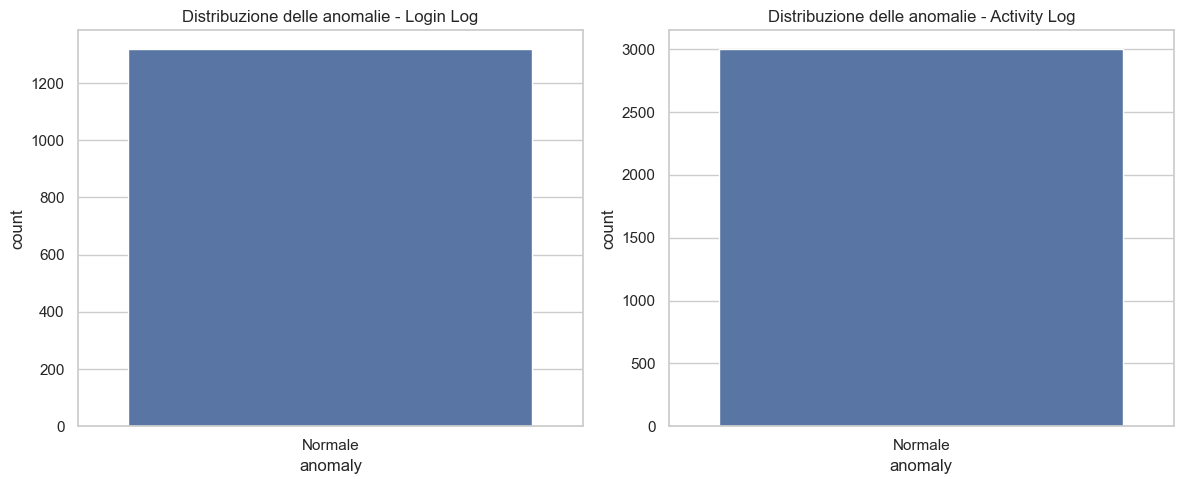

In [124]:
# Representamos visualmente cuántos casos normales y anómalos
# hay en Login Log y Activity Log.
# Rappresentiamo visivamente quanti casi normali e anomali
# ci sono in Login Log e Activity Log.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras para anomalías en login.
# Grafico a barre per le anomalie nel login.
sns.countplot(data=login_df, x="anomaly", ax=axes[0])
axes[0].set_title("Distribuzione delle anomalie - Login Log")
axes[0].set_xticklabels(["Normale", "Anomalo"])

# Gráfico de barras para anomalías en actividad.
# Grafico a barre per le anomalie nell'attività.
sns.countplot(data=activity_df, x="anomaly", ax=axes[1])
axes[1].set_title("Distribuzione delle anomalie - Activity Log")
axes[1].set_xticklabels(["Normale", "Anomalo"])

plt.tight_layout()
plt.show()

Record per utente nel Login Log


user_name
Matteo Nicolosi    440
Diego Scardino     439
Emilio Sardo       439
Name: count, dtype: int64

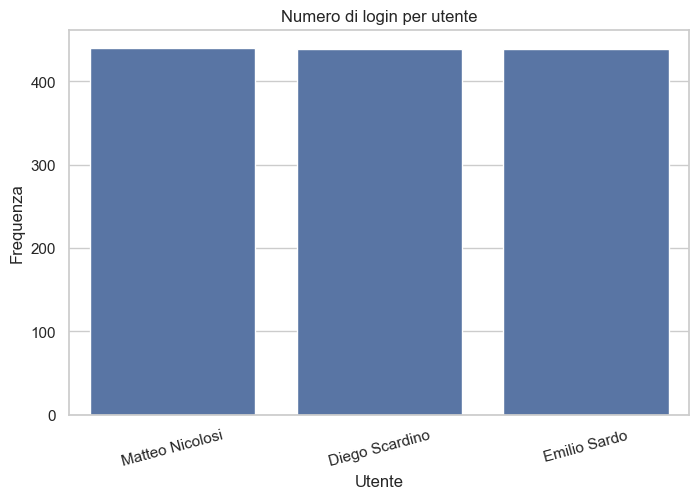

In [125]:
# Analizamos cuántos registros de login tiene cada usuario.
# Esto permite comprobar si todos los usuarios tienen
# suficiente representación en el dataset.
# Analizziamo quanti record di login ha ogni utente.
# Questo permette di verificare se tutti gli utenti hanno
# una rappresentazione sufficiente nel dataset.
print("Record per utente nel Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
# Visualizzazione grafica del numero di login per utente.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Numero di login per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.show()

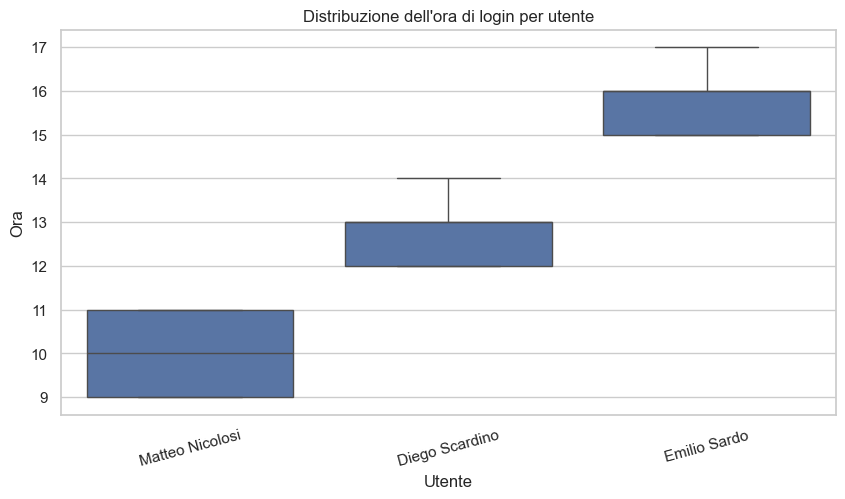

In [126]:
# El boxplot nos permite ver la dispersión de la hora de login
# para cada usuario y detectar visualmente posibles valores atípicos.
# Il boxplot ci permette di vedere la dispersione dell'ora di login
# per ogni utente e di rilevare visivamente possibili valori anomali.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di login per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

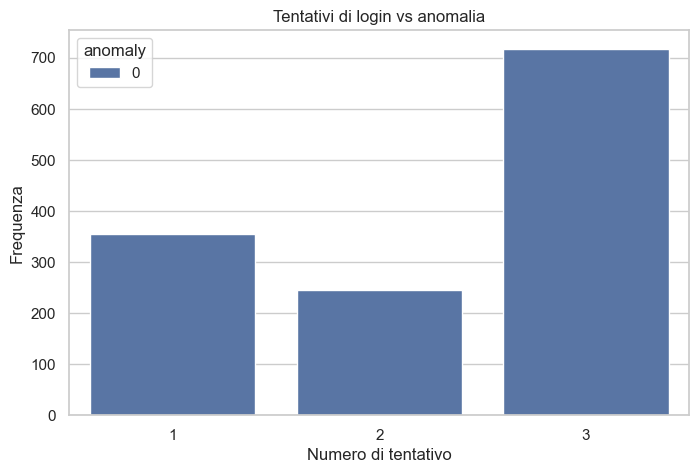

In [127]:
# Observamos cuántos logins se realizan al primer intento,
# segundo intento, etc., y si existe relación con la anomalía.
# Osserviamo quanti login vengono effettuati al primo tentativo,
# al secondo tentativo, ecc., e se esiste una relazione con l'anomalia.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="attempt", hue="anomaly")
plt.title("Tentativi di login vs anomalia")
plt.xlabel("Numero di tentativo")
plt.ylabel("Frequenza")
plt.show()

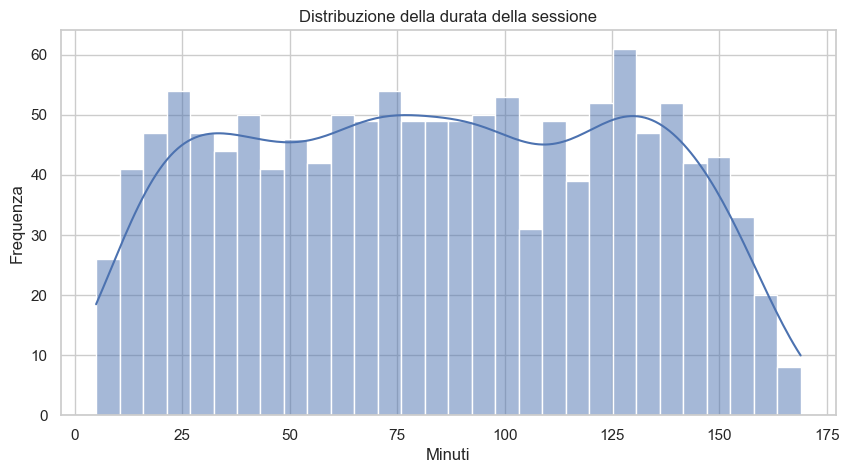

In [128]:
# Histograma de la duración de las sesiones de login.
# Se añade también una curva KDE para visualizar mejor la densidad.
# Istogramma della durata delle sessioni di login.
# Si aggiunge anche una curva KDE per visualizzare meglio la densità.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribuzione della durata della sessione")
plt.xlabel("Minuti")
plt.ylabel("Frequenza")
plt.show()

Azioni per utente


user_name        action_name
Diego Scardino   Copy           341
                 Share          313
                 Visualize      302
                 Edit            14
                 Delete           1
Emilio Sardo     Share          340
                 Copy           340
                 Visualize      339
                 Edit             6
Matteo Nicolosi  Share          347
                 Copy           330
                 Visualize      311
                 Edit            16
Name: count, dtype: int64

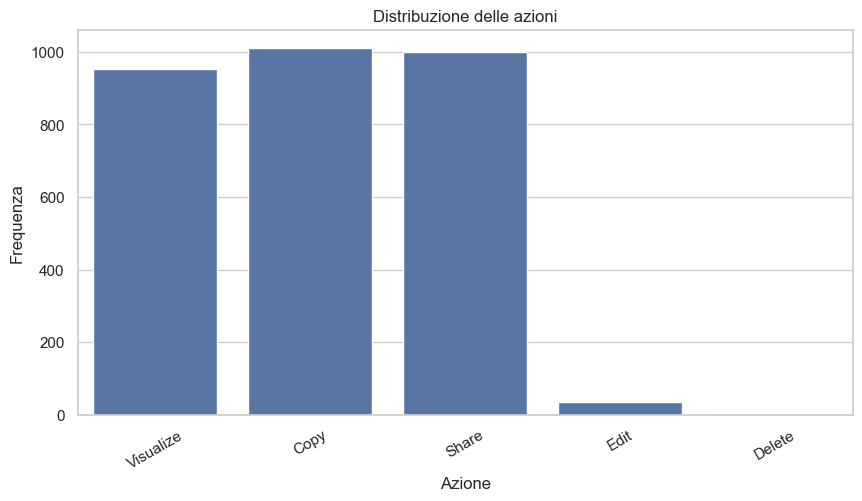

In [129]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# cada tipo de acción.
# Mostriamo un riepilogo di quante volte ogni utente esegue
# ogni tipo di azione.
print("Azioni per utente")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
# Grafico della distribuzione globale delle azioni.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribuzione delle azioni")
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.xticks(rotation=30)
plt.show()

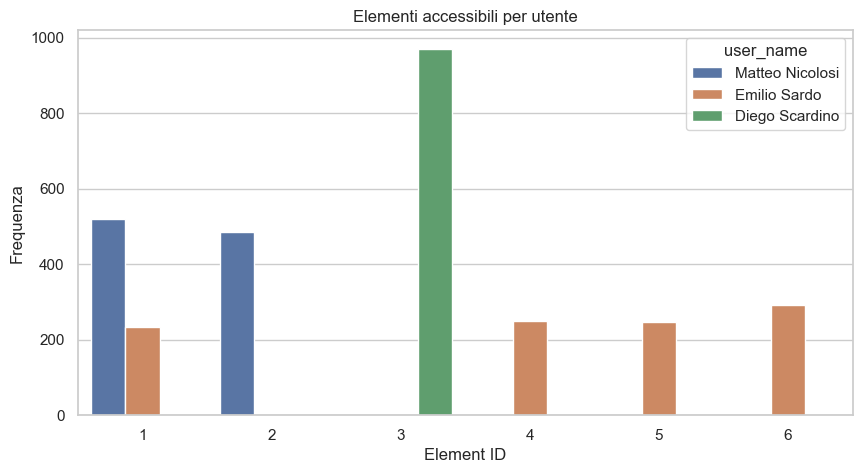

In [130]:
# Este gráfico permite ver qué element_id utiliza cada usuario.
# Es útil para detectar visualmente accesos fuera del conjunto esperado.
# Questo grafico permette di vedere quale element_id utilizza ogni utente.
# È utile per rilevare visivamente accessi al di fuori dell'insieme previsto.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementi accessibili per utente")
plt.xlabel("Element ID")
plt.ylabel("Frequenza")
plt.show()

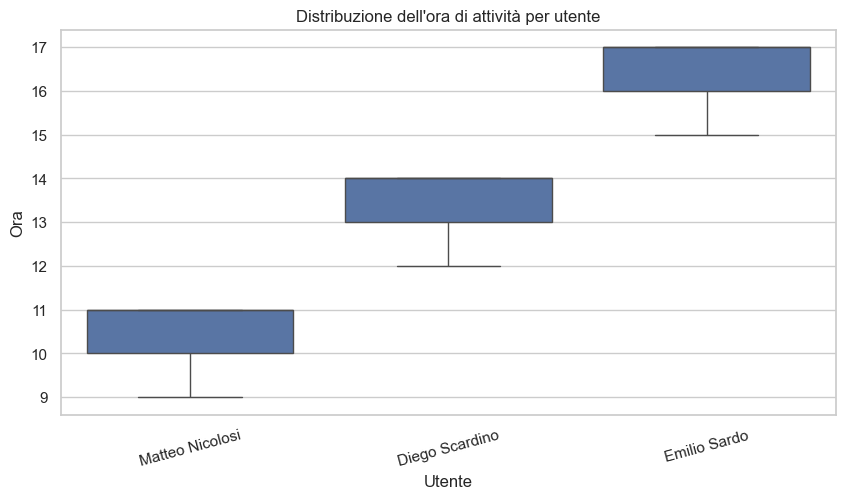

In [131]:
# Al igual que en login, usamos un boxplot para ver
# la distribución horaria de las actividades por usuario.
# Come nel login, utilizziamo un boxplot per vedere
# la distribuzione oraria delle attività per utente.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di attività per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

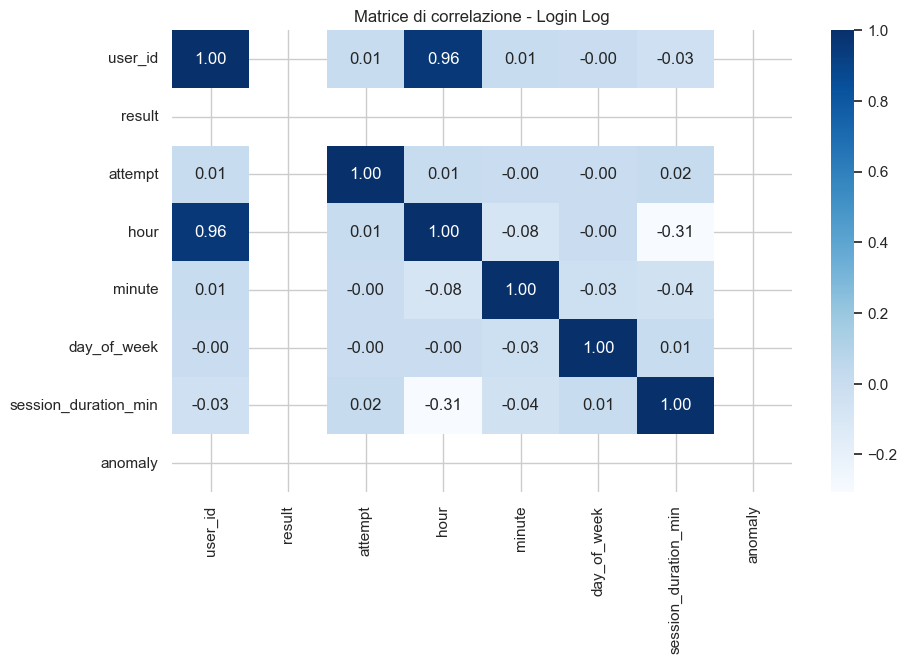

In [132]:
# Seleccionamos las variables numéricas más relevantes del dataset de login.
# Selezioniamo le variabili numeriche più rilevanti del dataset di login.
login_corr_cols = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min", "anomaly"]

# Heatmap de correlación.
# No implica causalidad, pero sí ayuda a explorar relaciones.
# Heatmap di correlazione.
# Non implica causalità, ma aiuta comunque a esplorare le relazioni.
plt.figure(figsize=(10, 6))
sns.heatmap(login_df[login_corr_cols].corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f")
plt.title("Matrice di correlazione - Login Log")
plt.show()

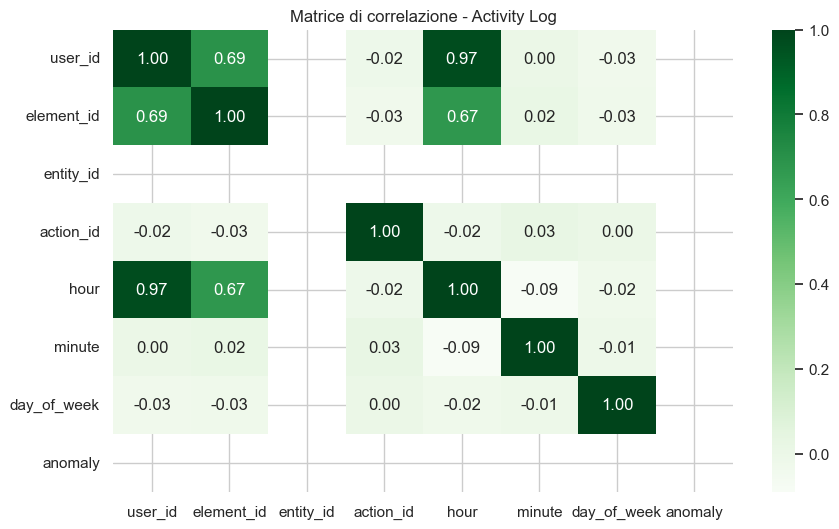

In [133]:
# Variables numéricas del dataset de actividad.
# Variabili numeriche del dataset di attività.
activity_corr_cols = ["user_id", "element_id", "entity_id", "action_id", "hour", "minute", "day_of_week", "anomaly"]

# Calculamos y representamos la matriz de correlación.
# Calcoliamo e rappresentiamo la matrice di correlazione.
plt.figure(figsize=(10, 6))
sns.heatmap(activity_df[activity_corr_cols].corr(numeric_only=True), annot=True, cmap="Greens", fmt=".2f")
plt.title("Matrice di correlazione - Activity Log")
plt.show()

In [134]:
# =========================
# PREPARACIÓN MODELO LOGIN
# =========================

# Creamos una copia del dataset de login con anomalías sintéticas
# para trabajar sobre ella sin modificar la versión anterior.
# Creiamo una copia del dataset di login con anomalie sintetiche
# per lavorare su di essa senza modificare la versione precedente.
login_model_df = login_df_model.copy()

# Convertimos la variable result a formato entero
# para que el modelo pueda tratarla como variable numérica.
# Convertiamo la variabile result in formato intero
# affinché il modello possa trattarla come variabile numerica.
login_model_df["result"] = login_model_df["result"].astype(int)

# Definimos las variables predictoras del modelo.
# Incluimos información de usuario, intento, tiempo y duración de sesión.
# Definiamo le variabili predittive del modello.
# Includiamo informazioni su utente, tentativo, tempo e durata della sessione.
features_login = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min"]

# Definimos la variable objetivo que el modelo debe predecir.
# En este caso, la etiqueta de anomalía.
# Definiamo la variabile target che il modello deve prevedere.
# In questo caso, l'etichetta di anomalia.
target_login = "anomaly"

# X contiene únicamente las variables de entrada del modelo.
# Estas son las características con las que aprenderá el algoritmo.
# X contiene unicamente le variabili di input del modello.
# Queste sono le caratteristiche con cui l'algoritmo apprenderà.
X_login = login_model_df[features_login].copy()

# y contiene la variable objetivo.
# Es la columna que indica si cada caso es normal o anómalo.
# y contiene la variabile target.
# È la colonna che indica se ogni caso è normale o anomalo.
y_login = login_model_df[target_login].copy()

# Rellenamos con 0 los posibles valores nulos en la duración de sesión
# para evitar errores en el entrenamiento del modelo.
# Riempiamo con 0 i possibili valori nulli nella durata della sessione
# per evitare errori nell'addestramento del modello.
X_login["session_duration_min"] = X_login["session_duration_min"].fillna(0)

# Dividimos el dataset en entrenamiento y prueba.
# Usamos stratify para mantener la proporción de clases en ambos conjuntos.
# Suddividiamo il dataset in training e test.
# Usiamo stratify per mantenere la proporzione delle classi in entrambi i set.
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_login, y_login, test_size=0.2, random_state=42, stratify=y_login
)

# Mostramos el tamaño del conjunto de entrenamiento.
# Esto permite verificar cuántos registros se usarán para entrenar.
# Mostriamo la dimensione del set di training.
# Questo permette di verificare quanti record verranno usati per addestrare.
print("Training Login:", Xl_train.shape)

# Mostramos el tamaño del conjunto de prueba.
# Así comprobamos cuántos registros quedan para evaluar el modelo.
# Mostriamo la dimensione del set di test.
# Così verifichiamo quanti record restano per valutare il modello.
print("Test Login:", Xl_test.shape)

# Mostramos la distribución de clases en el conjunto de entrenamiento.
# Esto ayuda a comprobar si existe desbalance entre normales y anomalías.
# Mostriamo la distribuzione delle classi nel set di training.
# Questo aiuta a verificare se esiste uno sbilanciamento tra normali e anomalie.
print("\nDistribuzione nel training:")
print(yl_train.value_counts())

# Mostramos la distribución de clases en el conjunto de prueba.
# Esto permite comprobar que el reparto es coherente con el entrenamiento.
# Mostriamo la distribuzione delle classi nel set di test.
# Questo permette di verificare che la suddivisione sia coerente con il training.
print("\nDistribuzione nel test:")
print(yl_test.value_counts())

Training Login: (1054, 7)
Test Login: (264, 7)

Distribuzione nel training:
anomaly
0    896
1    158
Name: count, dtype: int64

Distribuzione nel test:
anomaly
0    224
1     40
Name: count, dtype: int64


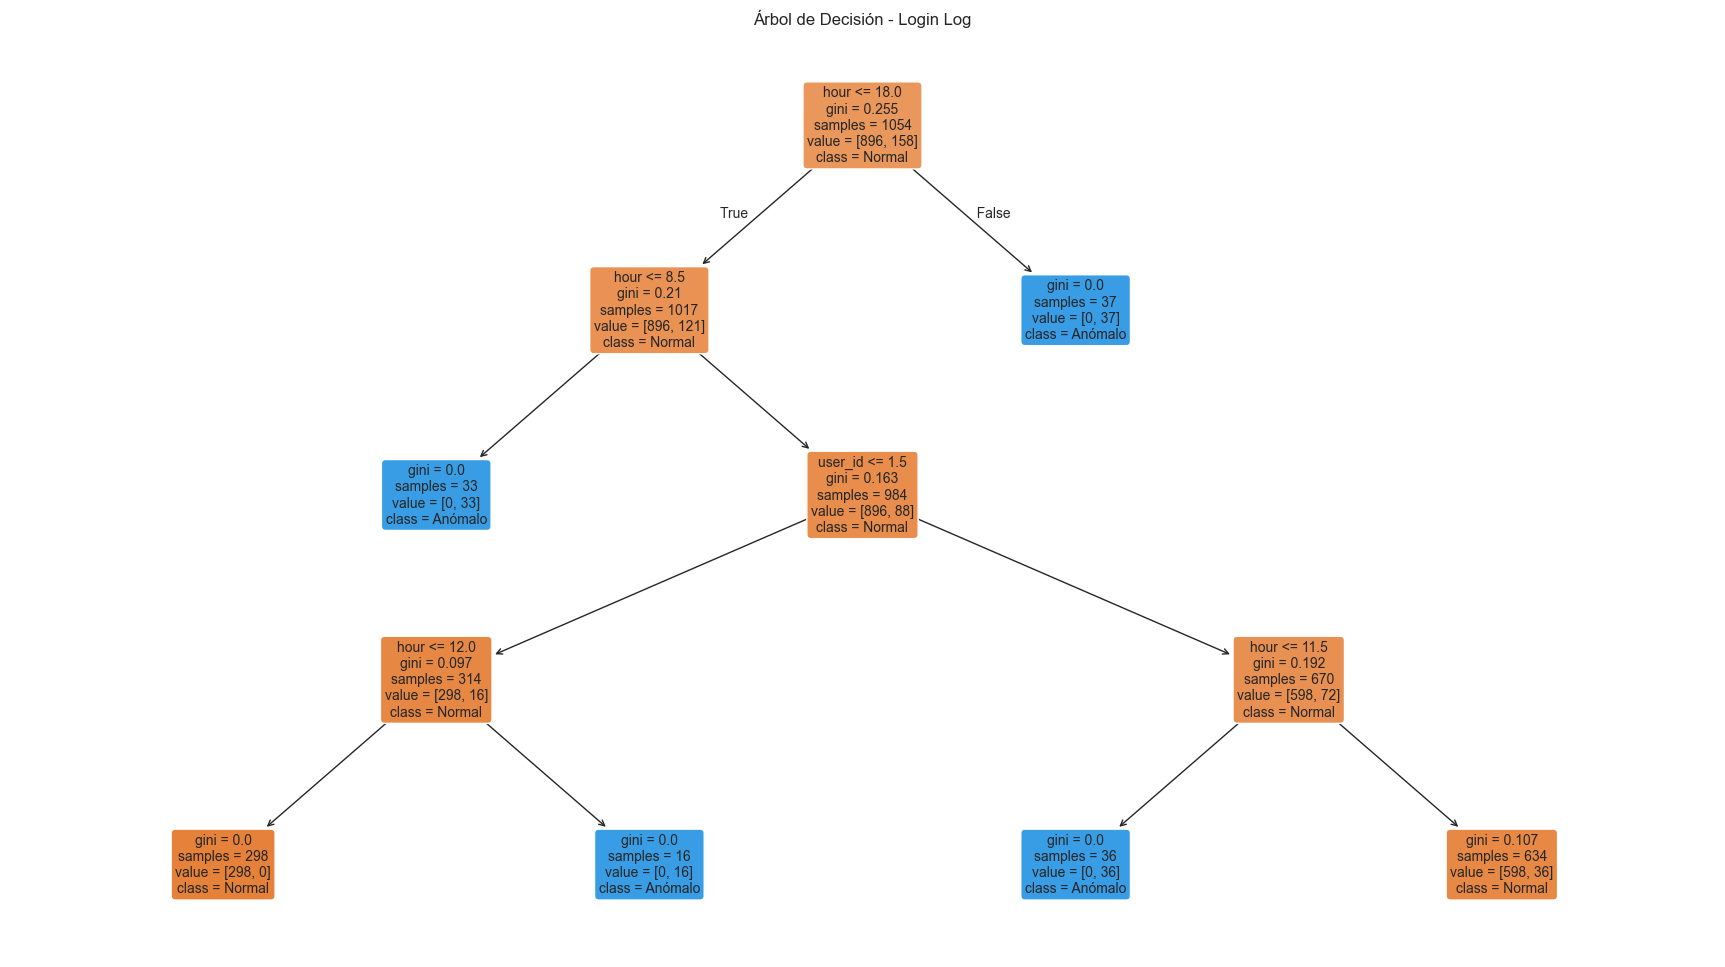

In [135]:
# Creamos el modelo de árbol de decisión.
# Configuramos sus hiperparámetros principales para controlar
# la forma y complejidad del árbol.
# Creiamo il modello di albero decisionale.
# Configuriamo i suoi iperparametri principali per controllare
# la forma e la complessità dell'albero.
login_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Entrenamos el árbol con los datos de entrenamiento.
# De esta forma el modelo aprende a separar casos normales y anómalos.
# Addestriamo l'albero con i dati di training.
# In questo modo il modello impara a separare i casi normali da quelli anomali.
login_tree.fit(Xl_train, yl_train)

# Definimos el tamaño de la figura para que el árbol
# se visualice de forma clara y legible.
# Definiamo la dimensione della figura affinché l'albero
# venga visualizzato in modo chiaro e leggibile.
plt.figure(figsize=(22, 12))

# Dibujamos el árbol de decisión indicando las variables,
# las clases objetivo y un estilo visual más comprensible.
# Disegniamo l'albero decisionale indicando le variabili,
# le classi target e uno stile visivo più comprensibile.
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=10
)

# Añadimos un título al gráfico para identificarlo fácilmente.
# Aggiungiamo un titolo al grafico per identificarlo facilmente.
plt.title("Árbol de Decisión - Login Log")

# Mostramos el gráfico final en pantalla.
# Mostriamo il grafico finale a schermo.
plt.show()

In [136]:
# Generamos predicciones sobre el conjunto de test,
# es decir, sobre datos no vistos durante el entrenamiento.
# Generiamo predizioni sul set di test,
# cioè su dati non visti durante l'addestramento.
yl_pred = login_tree.predict(Xl_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Login:", accuracy_score(yl_test, yl_pred))

# El classification report ofrece precisión, recall y f1-score.
# Estas métricas son más informativas que la accuracy,
# especialmente si hay desbalance de clases.
# Il classification report fornisce precision, recall e f1-score.
# Queste metriche sono più informative dell'accuracy,
# soprattutto se c'è uno sbilanciamento tra le classi.
print("\nClassification Report - Login")
print(classification_report(yl_test, yl_pred))

Accuracy Login: 0.9545454545454546

Classification Report - Login
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       224
           1       1.00      0.70      0.82        40

    accuracy                           0.95       264
   macro avg       0.97      0.85      0.90       264
weighted avg       0.96      0.95      0.95       264



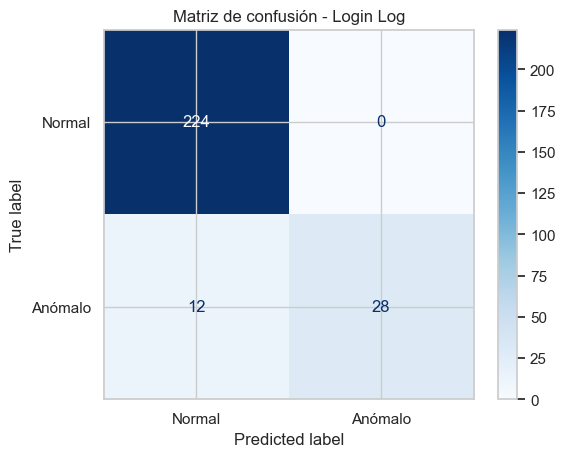

In [137]:
# La matriz de confusión muestra:
# - verdaderos normales
# - falsos positivos
# - falsos negativos
# - verdaderos anómalos
# La matrice di confusione mostra:
# - veri normali
# - falsi positivi
# - falsi negativi
# - veri anomali

# Calculamos la matriz de confusión indicando explícitamente
# las clases 0 y 1 para mantener siempre el mismo orden.
# Calcoliamo la matrice di confusione indicando esplicitamente
# le classi 0 e 1 per mantenere sempre lo stesso ordine.
cm_login = confusion_matrix(yl_test, yl_pred, labels=[0, 1])

# Creamos el objeto de visualización de la matriz
# y definimos las etiquetas legibles para cada clase.
# Creiamo l'oggetto di visualizzazione della matrice
# e definiamo le etichette leggibili per ogni classe.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_login,
    display_labels=["Normal", "Anómalo"]
)

# Dibujamos la matriz usando una paleta de colores azules.
# Disegniamo la matrice usando una palette di colori blu.
disp.plot(cmap="Blues")

# Añadimos un título al gráfico para identificarlo claramente.
# Aggiungiamo un titolo al grafico per identificarlo chiaramente.
plt.title("Matriz de confusión - Login Log")

# Mostramos el gráfico en pantalla.
# Mostriamo il grafico a schermo.
plt.show()

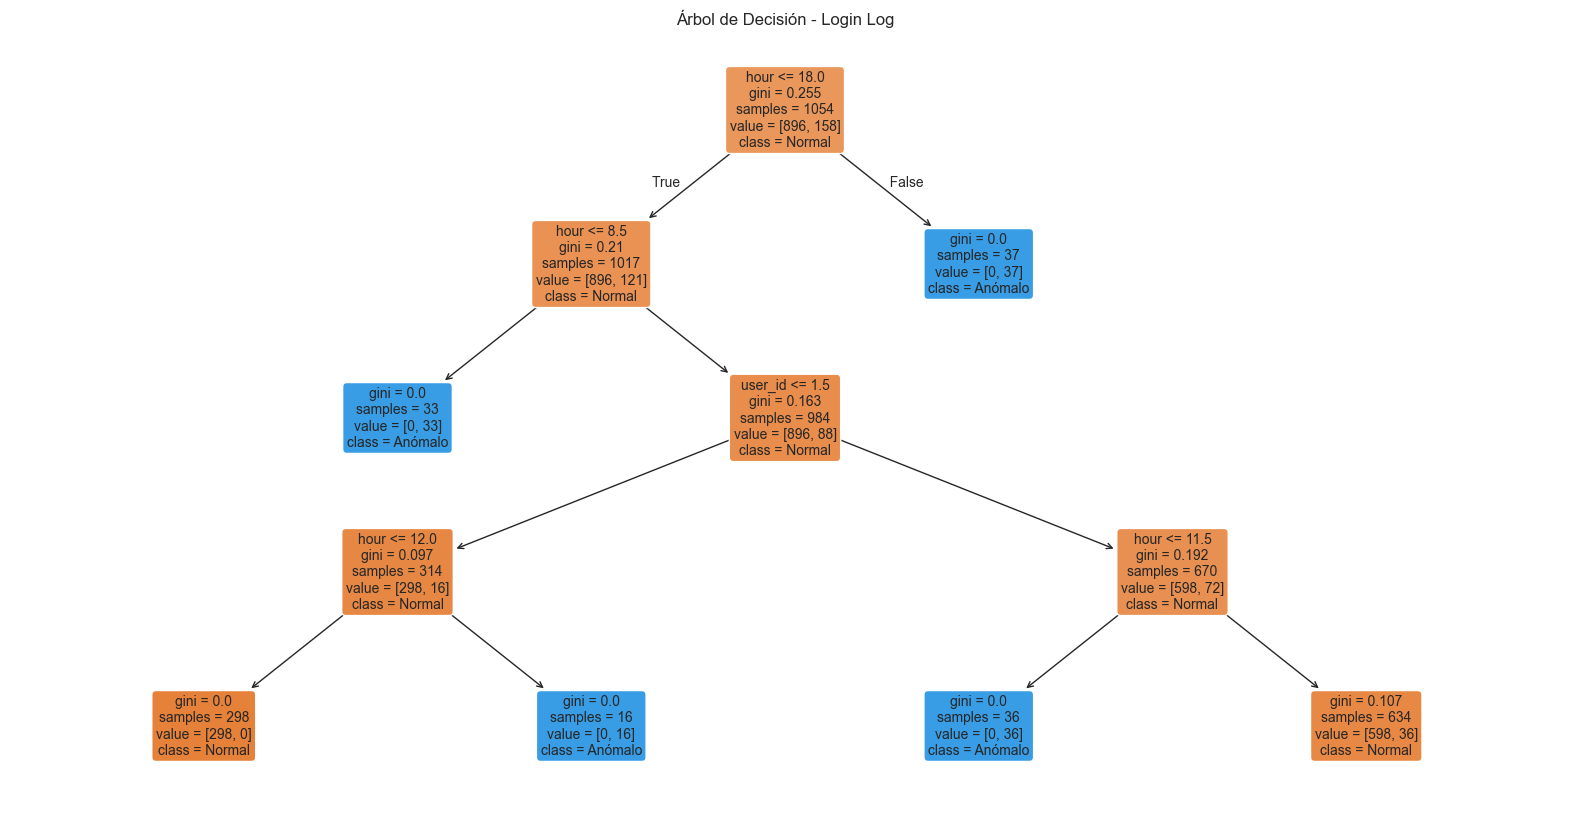

In [ ]:
# Dibujamos el árbol completo para entender
# qué decisiones toma el modelo y en qué variables se apoya.
# Disegniamo l'albero completo per capire
# quali decisioni prende il modello e su quali variabili si basa.
plt.figure(figsize=(20, 10))

# Representamos gráficamente el árbol de decisión
# mostrando variables, clases y nodos coloreados.
# Rappresentiamo graficamente l'albero decisionale
# mostrando variabili, classi e nodi colorati.
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=10
)

# Añadimos un título descriptivo al gráfico.
# Aggiungiamo un titolo descrittivo al grafico.
plt.title("Árbol de Decisión - Login Log")

# Mostramos el árbol en pantalla.
# Mostriamo l'albero a schermo.
plt.show()
#actividad

In [139]:
# export_text transforma el árbol a una representación textual.
# Esto facilita incluir reglas del modelo en documentación o informes.
# export_text trasforma l'albero in una rappresentazione testuale.
# Questo facilita l'inclusione delle regole del modello nella documentazione o nei report.
rules_login = export_text(login_tree, feature_names=features_login)
print(rules_login)

|--- hour <= 18.00
|   |--- hour <= 8.50
|   |   |--- class: 1
|   |--- hour >  8.50
|   |   |--- user_id <= 1.50
|   |   |   |--- hour <= 12.00
|   |   |   |   |--- class: 0
|   |   |   |--- hour >  12.00
|   |   |   |   |--- class: 1
|   |   |--- user_id >  1.50
|   |   |   |--- hour <= 11.50
|   |   |   |   |--- class: 1
|   |   |   |--- hour >  11.50
|   |   |   |   |--- class: 0
|--- hour >  18.00
|   |--- class: 1



In [140]:
# =========================
# RECREAR LA VARIABLE OBJETIVO anomaly
# =========================

# Recalculamos anomaly sobre la copia modificada
# Ricalcoliamo anomaly sulla copia modificata
activity_df_model["anomaly"] = activity_df_model.apply(activity_is_anomalous_v2, axis=1)

# Volvemos a crear el dataset final de modelado
# Ricreiamo il dataset finale di modellazione
activity_model_df = activity_df_model.copy()

# Rehacemos las variables derivadas por si acaso
# Ricreiamo le variabili derivate per sicurezza
activity_model_df["hour_decimal"] = (
    activity_model_df["hour"] + activity_model_df["minute"] / 60
)

# Indicamos si el elemento usado está permitido para ese usuario
# Indichiamo se l'elemento usato è consentito per quell'utente
activity_model_df["is_allowed_element"] = activity_model_df.apply(
    lambda row: 1 if row["element_id"] in allowed_elements.get(row["user_id"], []) else 0,
    axis=1
)

# Función para comprobar si la hora está dentro de la ventana permitida del usuario
# Funzione per verificare se l'ora rientra nella finestra consentita dell'utente
def is_allowed_user_hour(row):
    user_id = row["user_id"]
    hour = row["hour"]
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        return 1 if start_hour <= hour < end_hour else 0
    return 0

# Aplicamos la función para generar la nueva variable binaria
# Applichiamo la funzione per generare la nuova variabile binaria
activity_model_df["is_allowed_user_hour"] = activity_model_df.apply(
    is_allowed_user_hour,
    axis=1
)

# Marcamos si el registro pertenece a un día laborable
# Contrassegniamo se il record appartiene a un giorno lavorativo
activity_model_df["is_weekday"] = activity_model_df["day_of_week"].between(0, 4).astype(int)

# Mostramos las columnas disponibles en el dataset final
# Mostriamo le colonne disponibili nel dataset finale
print(activity_model_df.columns.tolist())

# Mostramos la distribución de la variable objetivo
# Mostriamo la distribuzione della variabile target
print("\nDistribuzione di anomaly:")
print(activity_model_df["anomaly"].value_counts())

['activity_log_id', 'user_id', 'element_id', 'entity_id', 'action_id', 'logged_at', 'user_name', 'action_name', 'hour', 'minute', 'day_of_week', 'date', 'is_weekday', 'is_working_hours', 'anomaly', 'hour_decimal', 'is_allowed_element', 'is_allowed_user_hour']

Distribuzione di anomaly:
anomaly
0    2515
1     485
Name: count, dtype: int64


In [141]:
# =========================
# PREPARACIÓN MODELO ACTIVITY
# =========================

# Definimos las variables predictoras que usará el modelo
# Definiamo le variabili predittive che userà il modello
features_activity = [
    "user_id",
    "element_id",
    "entity_id",
    "action_id",
    "hour",
    "minute",
    "day_of_week",
    "hour_decimal",
    "is_allowed_element",
    "is_allowed_user_hour",
    "is_weekday"
]

# Definimos la variable objetivo
# Definiamo la variabile target
target_activity = "anomaly"

# Creamos la matriz de entrada con las variables seleccionadas
# Creiamo la matrice di input con le variabili selezionate
X_activity = activity_model_df[features_activity].copy()

# Creamos el vector objetivo con la etiqueta de anomalía
# Creiamo il vettore target con l'etichetta di anomalia
y_activity = activity_model_df[target_activity].copy()

# Dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases
# Suddividiamo i dati in training e test mantenendo la proporzione delle classi
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_activity,
    y_activity,
    test_size=0.2,
    random_state=42,
    stratify=y_activity
)

# Mostramos el tamaño del conjunto de entrenamiento
# Mostriamo la dimensione del set di training
print("Train Activity:", Xa_train.shape)

# Mostramos el tamaño del conjunto de prueba
# Mostriamo la dimensione del set di test
print("Test Activity:", Xa_test.shape)

# Mostramos la distribución de clases en entrenamiento
# Mostriamo la distribuzione delle classi nel training
print("\nDistribuzione nel training:")
print(ya_train.value_counts())

# Mostramos la distribución de clases en prueba
# Mostriamo la distribuzione delle classi nel test
print("\nDistribuzione nel test:")
print(ya_test.value_counts())

Train Activity: (2400, 11)
Test Activity: (600, 11)

Distribuzione nel training:
anomaly
0    2012
1     388
Name: count, dtype: int64

Distribuzione nel test:
anomaly
0    503
1     97
Name: count, dtype: int64


In [142]:
# =========================
# MODELO ACTIVITY
# =========================

# Creamos el modelo de árbol de decisión para Activity
# Creiamo il modello di albero decisionale per Activity
activity_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento
# Addestriamo il modello con i dati di training
activity_tree.fit(Xa_train, ya_train)

# Mostramos un mensaje de confirmación
# Mostriamo un messaggio di conferma
print("Modello di Activity addestrato correttamente.")

# Mostramos la accuracy sobre el conjunto de entrenamiento
# Mostriamo l'accuracy sul set di training
print("Accuracy train:", activity_tree.score(Xa_train, ya_train))

# Mostramos la accuracy sobre el conjunto de prueba
# Mostriamo l'accuracy sul set di test
print("Accuracy test:", activity_tree.score(Xa_test, ya_test))

Modello di Activity addestrato correttamente.
Accuracy train: 1.0
Accuracy test: 1.0


In [143]:
# Predicción sobre test
# Predizione sul test
ya_pred = activity_tree.predict(Xa_test)

# Mostramos la accuracy global del modelo
# Mostriamo l'accuracy globale del modello
print("Accuracy Activity:", accuracy_score(ya_test, ya_pred))

# Mostramos el classification report con las métricas por clase
# Mostriamo il classification report con le metriche per classe
print("\nClassification Report - Activity")
print(
    classification_report(
        ya_test,
        ya_pred,
        labels=[0, 1],
        target_names=["Normal", "Anómalo"],
        zero_division=0
    )
)

Accuracy Activity: 1.0

Classification Report - Activity
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       503
     Anómalo       1.00      1.00      1.00        97

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



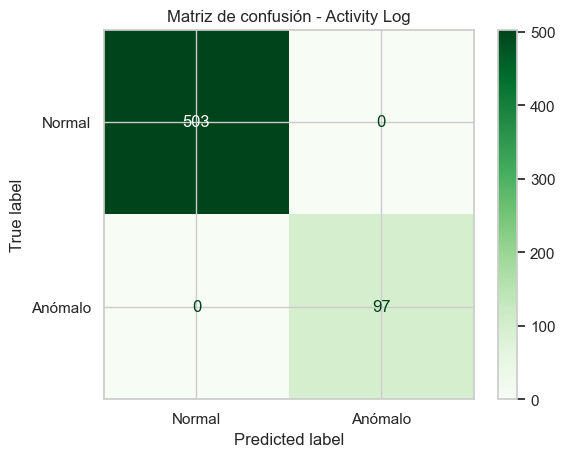

In [144]:
# Calculamos la matriz de confusión con las clases 0 y 1
# Calcoliamo la matrice di confusione con le classi 0 e 1
cm_activity = confusion_matrix(ya_test, ya_pred, labels=[0, 1])

# Creamos el objeto de visualización con etiquetas legibles
# Creiamo l'oggetto di visualizzazione con etichette leggibili
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_activity,
    display_labels=["Normal", "Anómalo"]
)

# Dibujamos la matriz con una escala de color verde
# Disegniamo la matrice con una scala di colore verde
disp.plot(cmap="Greens")

# Añadimos un título al gráfico
# Aggiungiamo un titolo al grafico
plt.title("Matriz de confusión - Activity Log")

# Mostramos la figura final
# Mostriamo la figura finale
plt.show()

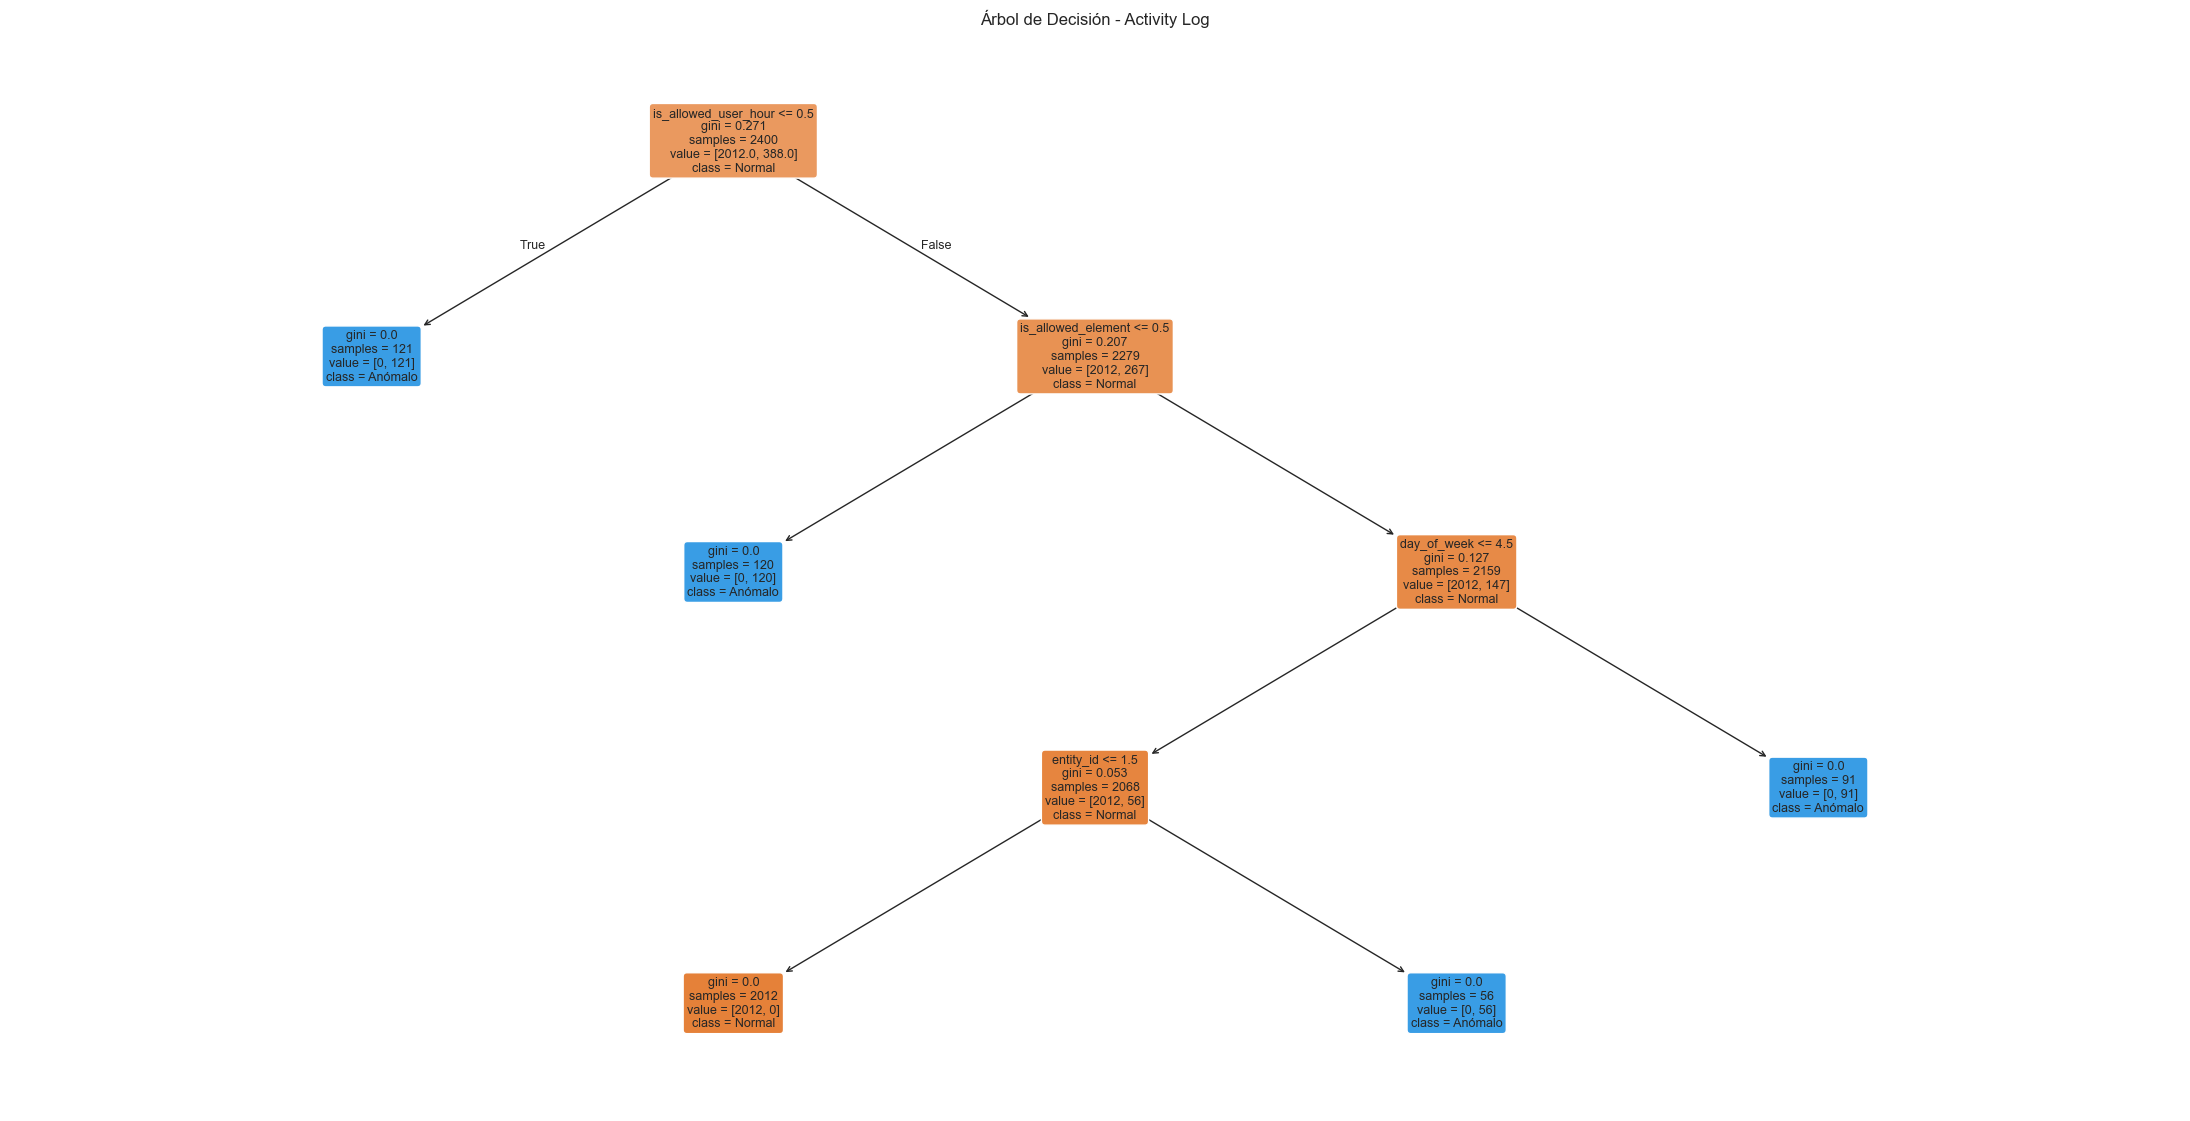

In [145]:
# Definimos el tamaño de la figura para visualizar mejor el árbol
# Definiamo la dimensione della figura per visualizzare meglio l'albero
plt.figure(figsize=(28, 14))

# Dibujamos el árbol de decisión con sus variables y clases
# Disegniamo l'albero decisionale con le sue variabili e classi
plot_tree(
    activity_tree,
    feature_names=features_activity,
    class_names=["Normal", "Anómalo"],
    filled=True,
    rounded=True,
    fontsize=9
)

# Añadimos un título descriptivo al gráfico
# Aggiungiamo un titolo descrittivo al grafico
plt.title("Árbol de Decisión - Activity Log")

# Mostramos la figura final en pantalla
# Mostriamo la figura finale a schermo
plt.show()

In [146]:
# Convertimos el árbol de actividad en una representación textual.
# Esto hace más fácil revisar y documentar las reglas de decisión.
# Convertiamo l'albero di attività in una rappresentazione testuale.
# Questo rende più semplice rivedere e documentare le regole decisionali.
rules_activity = export_text(activity_tree, feature_names=features_activity)
print(rules_activity)

|--- is_allowed_user_hour <= 0.50
|   |--- class: 1
|--- is_allowed_user_hour >  0.50
|   |--- is_allowed_element <= 0.50
|   |   |--- class: 1
|   |--- is_allowed_element >  0.50
|   |   |--- day_of_week <= 4.50
|   |   |   |--- entity_id <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- entity_id >  1.50
|   |   |   |   |--- class: 1
|   |   |--- day_of_week >  4.50
|   |   |   |--- class: 1



In [147]:
# =========================
# IMPORTANCIA DE VARIABLES
# =========================

# Creamos un DataFrame con cada variable y su nivel de importancia
# Creiamo un DataFrame con ogni variabile e il suo livello di importanza
importance_df = pd.DataFrame({
    "feature": features_activity,
    "importance": activity_tree.feature_importances_
}).sort_values("importance", ascending=False)

# Mostramos la tabla ordenada de mayor a menor importancia
# Mostriamo la tabella ordinata dalla maggiore alla minore importanza
display(importance_df)

,feature,importance
8,is_allowed_element,0.303523
9,is_allowed_user_hour,0.275320
6,day_of_week,0.253656
2,entity_id,0.167501
0,user_id,0.000000
1,element_id,0.000000
3,action_id,0.000000
4,hour,0.000000
5,minute,0.000000
7,hour_decimal,0.000000


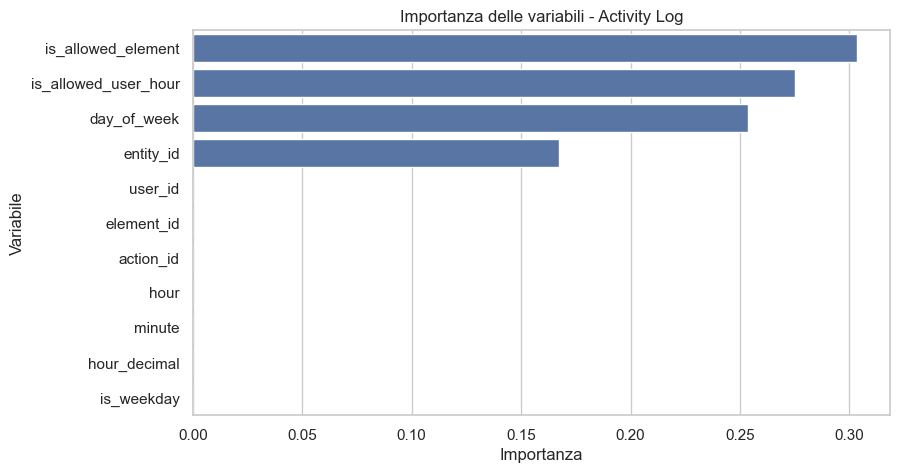

In [148]:
# Definimos el tamaño de la figura para visualizar mejor la gráfica
# Definiamo la dimensione della figura per visualizzare meglio il grafico
plt.figure(figsize=(9, 5))

# Dibujamos un gráfico de barras con la importancia de cada variable
# Disegniamo un grafico a barre con l'importanza di ogni variabile
sns.barplot(data=importance_df, x="importance", y="feature")

# Añadimos un título descriptivo al gráfico
# Aggiungiamo un titolo descrittivo al grafico
plt.title("Importanza delle variabili - Activity Log")

# Etiquetamos el eje X
# Etichettiamo l'asse X
plt.xlabel("Importanza")

# Etiquetamos el eje Y
# Etichettiamo l'asse Y
plt.ylabel("Variabile")

# Mostramos la gráfica final
# Mostriamo il grafico finale
plt.show()

In [149]:
# Aplicamos ambos modelos sobre todos los registros para comparar
# la etiqueta real generada por reglas con la predicción del árbol.
# Applichiamo entrambi i modelli su tutti i record per confrontare
# l'etichetta reale generata dalle regole con la previsione dell'albero.
login_df["predicted_anomaly"] = login_tree.predict(X_login)
activity_df["predicted_anomaly"] = activity_tree.predict(X_activity)

# Mostramos una comparación entre la anomalía real y la predicha
# en el dataset de login.
# Mostriamo un confronto tra l'anomalia reale e quella predetta
# nel dataset di login.
print("LOGIN - confronto reale vs previsione")
display(login_df[["login_log_id", "user_id", "user_name", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

# Hacemos lo mismo con el dataset de actividad.
# Facciamo lo stesso con il dataset di attività.
print("\nACTIVITY - confronto reale vs previsione")
display(activity_df[["activity_log_id", "user_id", "user_name", "element_id", "action_id", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

LOGIN - confronto reale vs previsione


,login_log_id,user_id,user_name,logged_at,anomaly,predicted_anomaly
0,3,1,Matteo Nicolosi,2026-01-01 09:06:55.942,0,0
1,4,2,Diego Scardino,2026-01-01 12:23:22.204,0,0
2,6,3,Emilio Sardo,2026-01-01 17:40:17.890,0,0
3,9,1,Matteo Nicolosi,2026-01-02 10:10:32.177,0,0
4,10,2,Diego Scardino,2026-01-02 12:47:29.386,0,0
5,12,3,Emilio Sardo,2026-01-02 16:12:38.083,0,0
6,13,1,Matteo Nicolosi,2026-01-05 09:20:03.990,0,0
7,16,2,Diego Scardino,2026-01-05 13:49:11.388,0,0
8,17,3,Emilio Sardo,2026-01-05 16:22:10.634,0,0
9,18,1,Matteo Nicolosi,2026-01-06 09:20:18.448,0,0



ACTIVITY - confronto reale vs previsione


,activity_log_id,user_id,user_name,element_id,action_id,logged_at,anomaly,predicted_anomaly
0,1,1,Matteo Nicolosi,2,1000000,2026-01-01 10:31:04.217,0,1
1,2,2,Diego Scardino,3,1000004,2026-01-01 14:37:47.860,0,0
2,3,3,Emilio Sardo,6,1000005,2026-01-01 17:44:36.455,0,0
3,4,1,Matteo Nicolosi,1,1000000,2026-01-02 10:14:36.855,0,0
4,5,1,Matteo Nicolosi,2,1000000,2026-01-02 10:15:31.904,0,0
5,6,1,Matteo Nicolosi,2,1000004,2026-01-02 10:34:10.221,0,0
6,7,1,Matteo Nicolosi,1,1000005,2026-01-02 10:45:38.782,0,0
7,8,1,Matteo Nicolosi,1,1000004,2026-01-02 10:50:27.144,0,0
8,9,1,Matteo Nicolosi,2,1000005,2026-01-02 11:00:25.523,0,0
9,10,1,Matteo Nicolosi,1,1000005,2026-01-02 11:17:42.260,0,0


In [150]:
# Filtramos únicamente los registros que el modelo clasifica como anómalos.
# Filtriamo unicamente i record che il modello classifica come anomali.
login_anomalies = login_df[login_df["predicted_anomaly"] == 1].copy()

# Mostramos los casos anómalos detectados en login.
# Mostriamo i casi anomali rilevati nel login.
print("Casi anomali rilevati nel Login:")
display(
    login_anomalies[
        ["login_log_id", "user_id", "user_name", "result", "attempt", "logged_at", "logout_at", "hour"]
    ].sort_values("logged_at")
)

Casi anomali rilevati nel Login:


,login_log_id,user_id,user_name,result,attempt,logged_at,logout_at,hour
192,417,1,Matteo Nicolosi,True,3,2026-01-01 10:42:02.987,2026-01-01 11:40:37.554,10
578,1267,3,Emilio Sardo,True,2,2026-01-01 15:53:44.327,2026-01-01 17:43:41.604,15
770,1731,3,Emilio Sardo,True,3,2026-01-01 16:23:54.574,2026-01-01 17:43:11.107,16
962,2171,3,Emilio Sardo,True,2,2026-01-01 16:37:50.204,2026-01-01 17:48:11.993,16
771,1734,1,Matteo Nicolosi,True,3,2026-01-02 11:20:43.708,2026-01-02 11:41:05.022,11
...,...,...,...,...,...,...,...,...
377,836,3,Emilio Sardo,True,3,2026-03-27 16:55:02.600,2026-03-27 17:39:08.676,16
762,1713,1,Matteo Nicolosi,True,2,2026-03-30 11:14:41.957,2026-03-30 11:53:22.652,11
1148,2594,3,Emilio Sardo,True,3,2026-03-30 15:59:40.586,2026-03-30 17:40:49.559,15
572,1255,3,Emilio Sardo,True,3,2026-03-30 16:11:32.531,2026-03-30 17:38:20.007,16


In [151]:
# Filtramos las actividades marcadas como anómalas por el modelo.
# Filtriamo le attività contrassegnate come anomale dal modello.
activity_anomalies = activity_df[activity_df["predicted_anomaly"] == 1].copy()

# Mostramos los casos anómalos detectados en activity.
# Mostriamo i casi anomali rilevati in activity.
print("Casi anomali rilevati in Activity:")
display(
    activity_anomalies[
        ["activity_log_id", "user_id", "user_name", "element_id", "entity_id", "action_id", "action_name", "logged_at", "hour"]
    ].sort_values("logged_at")
)

Casi anomali rilevati in Activity:


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,action_name,logged_at,hour
0,1,1,Matteo Nicolosi,2,1,1000000,Visualize,2026-01-01 10:31:04.217,10
1360,1361,1,Matteo Nicolosi,2,1,1000005,Share,2026-01-01 11:38:22.967,11
929,930,1,Matteo Nicolosi,1,1,1000005,Share,2026-01-01 11:39:26.805,11
2236,2237,1,Matteo Nicolosi,2,1,1000004,Copy,2026-01-01 11:49:25.162,11
930,931,2,Diego Scardino,3,1,1000004,Copy,2026-01-01 13:13:07.401,13
...,...,...,...,...,...,...,...,...,...
430,431,3,Emilio Sardo,4,1,1000000,Visualize,2026-03-31 17:06:39.634,17
1359,1360,3,Emilio Sardo,1,1,1000004,Copy,2026-03-31 17:16:30.554,17
2230,2231,3,Emilio Sardo,6,1,1000000,Visualize,2026-03-31 17:33:27.027,17
926,927,3,Emilio Sardo,4,1,1000000,Visualize,2026-03-31 17:42:58.490,17


In [152]:
# Definimos una función que permite probar manualmente
# nuevos casos de login sin tener que rehacer todo el pipeline.
# Definiamo una funzione che permette di testare manualmente
# nuovi casi di login senza dover rifare tutta la pipeline.
def predict_login_anomaly(user_id, result, attempt, logged_at, logout_at):
    # Convertimos las fechas introducidas a datetime.
    # Convertiamo le date inserite in datetime.
    logged_at = pd.to_datetime(logged_at)
    logout_at = pd.to_datetime(logout_at)

    # Construimos un DataFrame con la misma estructura
    # de variables que espera el modelo.
    # Costruiamo un DataFrame con la stessa struttura
    # di variabili che il modello si aspetta.
    row = pd.DataFrame([{
        "user_id": user_id,
        "result": int(result),
        "attempt": attempt,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek,
        "session_duration_min": (logout_at - logged_at).total_seconds() / 60
    }])

    # Obtenemos la predicción y las probabilidades.
    # Otteniamo la previsione e le probabilità.
    pred = login_tree.predict(row)[0]
    prob = login_tree.predict_proba(row)[0]

    # Mostramos resultado.
    # Mostriamo il risultato.
    print("Previsione:", "ANOMALO" if pred == 1 else "NORMALE")
    print("Probabilità [Normale, Anomalo]:", prob)

# Ejemplo de uso:
# Esempio di utilizzo:
predict_login_anomaly(
    user_id=1,
    result=True,
    attempt=2,
    logged_at="2026-01-15 16:30:00",
    logout_at="2026-01-15 17:00:00"
)

Previsione: ANOMALO
Probabilità [Normale, Anomalo]: [0. 1.]


In [153]:
# Definimos una función para probar manualmente nuevos casos de activity
# Definiamo una funzione per testare manualmente nuovi casi di activity
def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    # Convertimos la fecha introducida a formato datetime
    # Convertiamo la data inserita in formato datetime
    logged_at = pd.to_datetime(logged_at)

    # Extraemos las variables temporales necesarias
    # Estraiamo le variabili temporali necessarie
    hour = logged_at.hour
    minute = logged_at.minute
    day_of_week = logged_at.dayofweek
    hour_decimal = hour + minute / 60

    # Comprobamos si el elemento está permitido para ese usuario
    # Verifichiamo se l'elemento è consentito per quell'utente
    is_allowed_element = 1 if element_id in allowed_elements.get(user_id, []) else 0

    # Comprobamos si la hora está dentro de la ventana habitual del usuario
    # Verifichiamo se l'ora rientra nella finestra abituale dell'utente
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        is_allowed_user_hour = 1 if start_hour <= hour < end_hour else 0
    else:
        is_allowed_user_hour = 0

    # Indicamos si el día es laborable o fin de semana
    # Indichiamo se il giorno è lavorativo o fine settimana
    is_weekday = 1 if day_of_week in [0, 1, 2, 3, 4] else 0

    # Construimos la fila con el formato que espera el modelo
    # Costruiamo la riga con il formato atteso dal modello
    row = pd.DataFrame([{
        "user_id": user_id,
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": hour,
        "minute": minute,
        "day_of_week": day_of_week,
        "hour_decimal": hour_decimal,
        "is_allowed_element": is_allowed_element,
        "is_allowed_user_hour": is_allowed_user_hour,
        "is_weekday": is_weekday
    }])

    # Obtenemos la predicción y las probabilidades
    # Otteniamo la previsione e le probabilità
    pred = activity_tree.predict(row)[0]
    prob = activity_tree.predict_proba(row)[0]

    # Mostramos el resultado final
    # Mostriamo il risultato finale
    print("Previsione:", "ANOMALO" if pred == 1 else "NORMALE")
    print("Probabilità [Normale, Anomalo]:", prob)

In [154]:
# Caso normal
# Caso normale
predict_activity_anomaly(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000003,
    logged_at="2026-01-15 10:15:00"
)

# Caso anómalo por horario
# Caso anomalo per orario
predict_activity_anomaly(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000003,
    logged_at="2026-01-15 20:30:00"
)

# Caso anómalo por elemento no permitido
# Caso anomalo per elemento non consentito
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000003,
    logged_at="2026-01-15 13:00:00"
)

# Caso anómalo por entidad no válida
# Caso anomalo per entità non valida
predict_activity_anomaly(
    user_id=3,
    element_id=6,
    entity_id=2,
    action_id=1000003,
    logged_at="2026-01-15 16:30:00"
)

Previsione: NORMALE
Probabilità [Normale, Anomalo]: [1. 0.]
Previsione: ANOMALO
Probabilità [Normale, Anomalo]: [0. 1.]
Previsione: ANOMALO
Probabilità [Normale, Anomalo]: [0. 1.]
Previsione: ANOMALO
Probabilità [Normale, Anomalo]: [0. 1.]


In [155]:
# Mostramos cuántos registros normales y anómalos existen en el dataset de actividad.
# Esto permite comprobar el balance general de la variable objetivo.
# Mostriamo quanti record normali e anomali esistono nel dataset di attività.
# Questo permette di verificare l'equilibrio generale della variabile target.
print(activity_df["anomaly"].value_counts())

# Analizamos cómo se distribuyen las anomalías según el tipo de acción (action_id).
# La tabla cruzada permite ver si determinadas acciones concentran más casos anómalos.
# Analizziamo come si distribuiscono le anomalie in base al tipo di azione (action_id).
# La tabella incrociata permette di vedere se determinate azioni concentrano più casi anomali.
print("\nAnomalie per action_id:")
print(pd.crosstab(activity_df["action_id"], activity_df["anomaly"]))

# Analizamos cómo se distribuyen las anomalías según el elemento accedido (element_id).
# Esto ayuda a detectar si ciertos elementos están asociados con más comportamientos sospechosos.
# Analizziamo come si distribuiscono le anomalie in base all'elemento accesso (element_id).
# Questo aiuta a rilevare se certi elementi sono associati a più comportamenti sospetti.
print("\nAnomalie per element_id:")
print(pd.crosstab(activity_df["element_id"], activity_df["anomaly"]))

# Analizamos cómo se distribuyen las anomalías por usuario.
# De este modo se puede ver si algún usuario concentra más eventos anómalos que el resto.
# Analizziamo come si distribuiscono le anomalie per utente.
# In questo modo si può vedere se qualche utente concentra più eventi anomali rispetto agli altri.
print("\nAnomalie per user_id:")
print(pd.crosstab(activity_df["user_id"], activity_df["anomaly"]))

# Calculamos la media de la variable anomaly agrupada por hora.
# Como anomaly toma valores 0 y 1, la media representa la proporción de anomalías en cada hora.
# Esto sirve para detectar franjas horarias con mayor frecuencia de comportamientos anómalos.
# Calcoliamo la media della variabile anomaly raggruppata per ora.
# Poiché anomaly assume valori 0 e 1, la media rappresenta la proporzione di anomalie in ogni ora.
# Questo serve a rilevare fasce orarie con una maggiore frequenza di comportamenti anomali.
print("\nAnomalie per hour:")
print(activity_df.groupby("hour")["anomaly"].mean().sort_index())

anomaly
0    3000
Name: count, dtype: int64

Anomalie per action_id:
anomaly       0
action_id      
1000000     952
1000002      36
1000003       1
1000004    1011
1000005    1000

Anomalie per element_id:
anomaly       0
element_id     
1           754
2           485
3           971
4           250
5           247
6           293

Anomalie per user_id:
anomaly     0
user_id      
1        1004
2         971
3        1025

Anomalie per hour:
hour
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
Name: anomaly, dtype: float64


In [156]:
# Creamos el modelo de regresión logística
# Creiamo il modello di regressione logistica
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
# Addestriamo il modello con i dati di training
log_model.fit(Xa_train, ya_train)

# Generamos predicciones sobre el conjunto de prueba
# Generiamo predizioni sul set di test
ya_pred_log = log_model.predict(Xa_test)

# Mostramos la accuracy global del modelo
# Mostriamo l'accuracy globale del modello
print("Accuracy Logistic Regression:", accuracy_score(ya_test, ya_pred_log))

# Mostramos el classification report con métricas por clase
# Mostriamo il classification report con metriche per classe
print(classification_report(ya_test, ya_pred_log, labels=[0, 1], target_names=["Normal", "Anómalo"], zero_division=0))

Accuracy Logistic Regression: 1.0
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       503
     Anómalo       1.00      1.00      1.00        97

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



RANDOM FOREST

In [157]:
# =========================
# ENTRENAMIENTO DEL MODELO RANDOM FOREST
# =========================

# Creamos el modelo Random Forest.
# Parámetros elegidos:
# - n_estimators: número de árboles que formarán el bosque.
# - max_depth: profundidad máxima de cada árbol, para evitar sobreajuste excesivo.
# - min_samples_split: mínimo de muestras para dividir un nodo.
# - min_samples_leaf: mínimo de muestras que debe tener una hoja.
# - random_state: garantiza reproducibilidad.
# - n_jobs=-1: usa todos los núcleos del procesador disponibles.
# Creiamo il modello Random Forest.
# Parametri scelti:
# - n_estimators: numero di alberi che formeranno la foresta.
# - max_depth: profondità massima di ogni albero, per evitare un overfitting eccessivo.
# - min_samples_split: numero minimo di campioni per dividere un nodo.
# - min_samples_leaf: numero minimo di campioni che deve avere una foglia.
# - random_state: garantisce la riproducibilità.
# - n_jobs=-1: utilizza tutti i core del processore disponibili.
rf_activity = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo con los datos de entrenamiento.
# Addestriamo il modello con i dati di training.
rf_activity.fit(Xa_train, ya_train)

# Mostramos confirmación y accuracy en train/test
# para tener una primera visión de si hay sobreajuste.
# Mostriamo una conferma e l'accuracy su train/test
# per avere una prima idea dell'eventuale presenza di overfitting.
print("Modello Random Forest addestrato correttamente.")
print("Accuracy train:", rf_activity.score(Xa_train, ya_train))
print("Accuracy test:", rf_activity.score(Xa_test, ya_test))

Modello Random Forest addestrato correttamente.
Accuracy train: 1.0
Accuracy test: 1.0


In [158]:
# =========================
# EVALUACIÓN DEL MODELO RANDOM FOREST
# =========================

# Generamos predicciones sobre el conjunto de prueba.
# Generiamo predizioni sul set di test.
ya_pred_rf = rf_activity.predict(Xa_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Random Forest:", accuracy_score(ya_test, ya_pred_rf))

# El classification report muestra métricas más completas:
# - precision
# - recall
# - f1-score
# Esto es especialmente importante en problemas de detección de anomalías.
# Il classification report mostra metriche più complete:
# - precision
# - recall
# - f1-score
# Questo è particolarmente importante nei problemi di rilevamento delle anomalie.
print("\nClassification Report - Random Forest (Activity Log)")
print(
    classification_report(
        ya_test,
        ya_pred_rf,
        labels=[0, 1],
        target_names=["Normal", "Anómalo"],
        zero_division=0
    )
)

Accuracy Random Forest: 1.0

Classification Report - Random Forest (Activity Log)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       503
     Anómalo       1.00      1.00      1.00        97

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



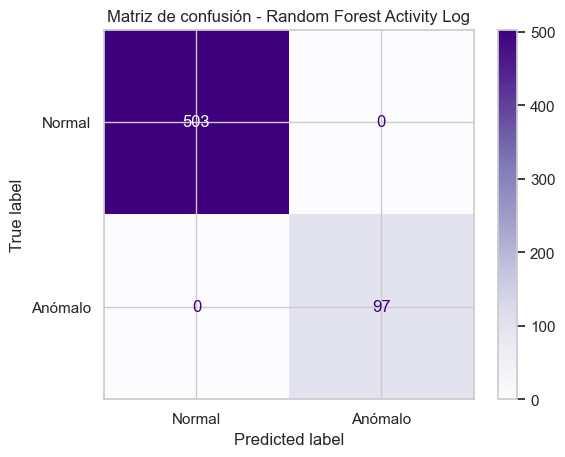

In [159]:
# =========================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# =========================

# Calculamos la matriz de confusión forzando las clases [0, 1]
# para que siempre se represente correctamente.
# Calcoliamo la matrice di confusione forzando le classi [0, 1]
# affinché venga sempre rappresentata correttamente.
cm_rf = confusion_matrix(ya_test, ya_pred_rf, labels=[0, 1])

# Mostramos la matriz con etiquetas claras.
# Mostriamo la matrice con etichette chiare.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Anómalo"]
)

# Dibujamos la matriz usando una escala de color púrpura.
# Disegniamo la matrice usando una scala di colore viola.
disp.plot(cmap="Purples")

# Añadimos un título descriptivo al gráfico.
# Aggiungiamo un titolo descrittivo al grafico.
plt.title("Matriz de confusión - Random Forest Activity Log")

# Mostramos la figura final en pantalla.
# Mostriamo la figura finale a schermo.
plt.show()

In [160]:
# =========================
# IMPORTANCIA DE VARIABLES - RANDOM FOREST
# =========================

# Extraemos la importancia de cada variable utilizada por el modelo.
# Estraiamo l'importanza di ogni variabile utilizzata dal modello.
rf_importance_df = pd.DataFrame({
    "feature": X_activity.columns,
    "importance": rf_activity.feature_importances_
}).sort_values("importance", ascending=False)

# Mostramos la tabla ordenada de mayor a menor importancia.
# Mostriamo la tabella ordinata dalla maggiore alla minore importanza.
display(rf_importance_df)

,feature,importance
8,is_allowed_element,0.277909
9,is_allowed_user_hour,0.251764
2,entity_id,0.128600
10,is_weekday,0.128066
6,day_of_week,0.112461
7,hour_decimal,0.046964
4,hour,0.033103
1,element_id,0.015751
5,minute,0.002512
0,user_id,0.002147


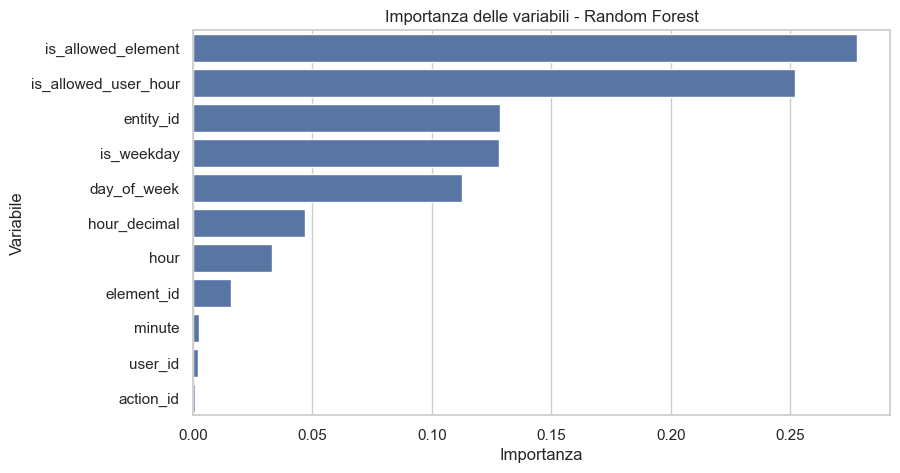

In [161]:
# =========================
# GRÁFICA DE IMPORTANCIA DE VARIABLES
# =========================

# Definimos el tamaño de la figura para visualizar mejor la gráfica.
# Definiamo la dimensione della figura per visualizzare meglio il grafico.
plt.figure(figsize=(9, 5))

# Dibujamos un gráfico de barras con la importancia de cada variable.
# Disegniamo un grafico a barre con l'importanza di ogni variabile.
sns.barplot(data=rf_importance_df, x="importance", y="feature")

# Añadimos un título descriptivo al gráfico.
# Aggiungiamo un titolo descrittivo al grafico.
plt.title("Importanza delle variabili - Random Forest")

# Etiquetamos el eje X.
# Etichettiamo l'asse X.
plt.xlabel("Importanza")

# Etiquetamos el eje Y.
# Etichettiamo l'asse Y.
plt.ylabel("Variabile")

# Mostramos la gráfica final.
# Mostriamo il grafico finale.
plt.show()

In [162]:
# =========================
# COMPARACIÓN ENTRE DECISION TREE Y RANDOM FOREST
# =========================

# Mostramos primero el resultado del árbol de decisión.
# Mostriamo prima il risultato dell'albero decisionale.
print("DECISION TREE")
print("Accuracy test:", accuracy_score(ya_test, ya_pred))

# Mostramos después el resultado del modelo Random Forest.
# Mostriamo dopo il risultato del modello Random Forest.
print("\nRANDOM FOREST")
print("Accuracy test:", accuracy_score(ya_test, ya_pred_rf))

DECISION TREE
Accuracy test: 1.0

RANDOM FOREST
Accuracy test: 1.0


# CONCLUSIONES FINALES

A lo largo de este proyecto se han cargado, analizado y preparado dos fuentes principales de datos, **Login Log** y **Activity Log**, con el objetivo de construir una primera **PoC de detección de anomalías** en el comportamiento de los usuarios. Para ello, se han transformado las variables temporales más relevantes, generando información útil como la **hora**, el **minuto**, el **día de la semana** y la **duración de la sesión**, lo que ha permitido enriquecer el análisis y preparar correctamente los datos para el modelado.

A partir de las reglas de negocio definidas, se han implementado criterios de detección para identificar comportamientos anómalos, tales como **logins fuera de la franja horaria habitual del usuario**, accesos realizados **fuera de los días laborables**, actividades ejecutadas **fuera del horario permitido**, accesos a **elementos no autorizados**, acciones sobre **entity distinta de password** y eventos realizados **fuera del flujo estándar esperado**. De esta manera, se ha construido una base sólida para etiquetar anomalías de forma coherente con el contexto funcional del sistema.

Sobre esta base, se han entrenado modelos de **Árbol de Decisión** para los datos de login y de actividad, ya que se trata de un enfoque especialmente adecuado para una primera PoC gracias a su **alta interpretabilidad**, su capacidad para **explicar la lógica de clasificación** y su utilidad para presentar resultados de forma clara y defendible ante negocio. Como mejora adicional, se ha incorporado también **Random Forest**, con el fin de reforzar la robustez del sistema. Este modelo ha permitido aportar **mayor estabilidad frente a variaciones del dataset**, **reducir el riesgo de sobreajuste**, **mejorar la capacidad de generalización** en datos no vistos y analizar la relevancia de las variables mediante sus importancias.

En conjunto, puede concluirse que el **Árbol de Decisión** representa el modelo más adecuado para explicar el comportamiento del sistema y la lógica de negocio, mientras que **Random Forest** constituye una evolución natural del mismo cuando se busca una solución más robusta y orientada a un futuro escenario de producción. Por tanto, el enfoque desarrollado resulta apropiado para una primera fase del proyecto, al combinar **reglas de negocio**, **modelos interpretables** y una primera mejora orientada a la **robustez predictiva**.

Como líneas de mejora futura, sería recomendable **ampliar el número de usuarios y casuísticas reales**, incorporar **secuencias completas de comportamiento** como `login -> actividad -> logout`, introducir **features agregadas por usuario y por día** y evolucionar hacia un **sistema en tiempo real** capaz de bloquear o revisar acciones sospechosas automáticamente. Todo ello permitiría aumentar progresivamente la precisión y utilidad operativa del sistema en un entorno real.

---

# CONCLUSIONI FINALI

Nel corso di questo progetto sono state caricate, analizzate e preparate due principali fonti di dati, **Login Log** e **Activity Log**, con l’obiettivo di costruire una prima **PoC per il rilevamento delle anomalie** nel comportamento degli utenti. A tal fine, sono state trasformate le variabili temporali più rilevanti, generando informazioni utili come **ora**, **minuto**, **giorno della settimana** e **durata della sessione**, così da arricchire l’analisi e preparare correttamente i dati per il modellamento.

A partire dalle regole di business definite, sono stati implementati criteri di rilevamento per identificare comportamenti anomali, come **login fuori dalla fascia oraria abituale dell’utente**, accessi effettuati **al di fuori dei giorni lavorativi**, attività eseguite **fuori dall’orario consentito**, accessi a **elementi non autorizzati**, azioni su **entity diversa da password** ed eventi effettuati **al di fuori del flusso standard previsto**. In questo modo è stata costruita una base solida per etichettare le anomalie in modo coerente con il contesto funzionale del sistema.

Su questa base, sono stati addestrati modelli di **Albero di Decisione** per i dati di login e di activity, poiché si tratta di un approccio particolarmente adatto a una prima PoC grazie alla sua **elevata interpretabilità**, alla capacità di **spiegare chiaramente la logica di classificazione** e alla sua utilità nel presentare risultati in modo comprensibile e difendibile dal punto di vista del business. Come miglioramento aggiuntivo, è stato inoltre introdotto **Random Forest**, con l’obiettivo di rafforzare la robustezza del sistema. Questo modello ha permesso di ottenere **maggiore stabilità rispetto alle variazioni del dataset**, **minore rischio di overfitting**, **migliore capacità di generalizzazione** su dati non visti e la possibilità di analizzare la rilevanza delle variabili attraverso le rispettive importanze.

Nel complesso, si può concludere che l’**Albero di Decisione** rappresenta il modello più adatto per spiegare il comportamento del sistema e la logica di business, mentre **Random Forest** costituisce una sua naturale evoluzione quando si desidera una soluzione più robusta e orientata a un futuro scenario di produzione. Di conseguenza, l’approccio sviluppato risulta appropriato per una prima fase del progetto, in quanto combina **regole di business**, **modelli interpretabili** e un primo miglioramento orientato alla **robustezza predittiva**.

Come possibili sviluppi futuri, sarebbe consigliabile **ampliare il numero di utenti e di casistiche reali**, includere **sequenze complete di comportamento** come `login -> attività -> logout`, introdurre **feature aggregate per utente e per giorno** ed evolvere verso un **sistema in tempo reale** capace di bloccare o sottoporre a revisione automatica le azioni sospette. Tutto ciò permetterebbe di aumentare progressivamente la precisione e l’utilità operativa del sistema in un contesto reale.